# Identitas

Rahajeng Febri Shafiyah

# Penjelasan tentang Dataset

Berikut penjelasan variable dari dataset :

| Atribut                       | Keterangan                                                                                       |
|-------------------------------|-------------------------------------------------------------------------------------------------|
| id                         | Nomor identitas untuk setiap pasien                    |
| gender                   | Jenis kelamin pasien                                    |
| age                     | Usia Pasien   |
| hypertension             | Pasien yang memiliki penyakit tekanan darah tinggi (1), dan tidak (0)|
| heartdisease      | Pasien yang memiliki penyakit jantung (1), dan tidak (0) |
| ever_maried      | Pasien pernah atau sedang menikah ("Yes"), tidak ("No")               |
| work_type     | Jenis pekerjaan pasien : <br> 1. private = karyawan swasta <br> 2. self-employed = wiraswasta/pengusaha <br> 3. never_worked =  tidak pernah bekerja <br> 4. govt_job = PNS <br> 5. children = anak-anak (belum bekerja)|
| residence_type       |  Jenis tempat tinggal pasien : <br> 1. rural = daerah pedesaan <br> 2. urban = daerah perkotaan|
| avg_glucose_level         | Rata-rata kadar gula dalam darah pasien  |
| bmi                     | Indeks massa tubuh pasien |
| smoking_status                      | Kebiasaan merokok pasien : <br> 1. never smoked = tidak pernah merokok <br> 2. formerly smoked = pernah merokok tetapi sudah berhenti <br> 3. smokes = masih merokok <br> 4. unknown = belum diketahui                                                          |
| stroke                        | Pasien yang pernah mengalami penyakit stroke (1), dan tidak (0)|


# Import Data

## Library yang digunakan

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro
import matplotlib.pyplot as plt
from scipy.stats import probplot
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

## Load Dataset

In [2]:
df = pd.read_csv('stroke.csv')

# Data Exploration

## Menampilkan data

**`df.head()`** menampilkan beberapa baris teratas atau pertama dari dataset

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,Male,44,1,0,Yes,Private,Urban,136.71,29.10,never smoked,0
1,2,Female,15,0,0,Yes,Self-employed,Urban,77.12,27.01,formerly smoked,1
2,3,Female,55,0,0,Yes,Never_worked,Rural,141.59,22.63,never smoked,0
3,4,Female,72,0,0,Yes,Never_worked,Rural,128.37,14.59,smokes,0
4,5,Male,38,1,0,No,children,Rural,135.48,28.36,smokes,0


## Info data

**`df.info()`** memberikan ringkasan struktur DataFrame, termasuk jumlah baris, kolom, tipe data, nilai non-null, dan penggunaan memori, membantu memahami data sebelum analisis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 126 non-null    int64  
 1   gender             126 non-null    object 
 2   age                126 non-null    int64  
 3   hypertension       126 non-null    int64  
 4   heart_disease      126 non-null    int64  
 5   ever_married       126 non-null    object 
 6   work_type          126 non-null    object 
 7   Residence_type     126 non-null    object 
 8   avg_glucose_level  126 non-null    float64
 9   bmi                126 non-null    float64
 10  smoking_status     126 non-null    object 
 11  stroke             126 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 11.9+ KB


Pada dataset ini terdapat 126 data dengan 12 kolom. Seluruh kolom non-null yang berarti tidak ada missing value atau data kosong. Memiliki 5 kolom dengan tipe data numerik atau int, 2 kolom dengan tipe data float atau kontinu, dan 5 kolom dengan tipe data kategorikal atau object.

## Menampilkan ringkasan statistik

**`Statistik deskriptif`** untuk melihat ringkasan statistik dari data numerik

In [6]:
df[['age', 'avg_glucose_level', 'bmi']].describe()

,age,avg_glucose_level,bmi
count,126.000000,126.000000,126.000000
mean,46.722222,103.012381,25.208571
std,23.258767,24.284384,5.347856
min,5.000000,50.000000,13.050000
25%,28.250000,84.077500,21.707500
50%,44.000000,101.540000,25.355000
75%,58.750000,119.717500,29.077500
max,100.000000,163.010000,35.590000


Dari hasil ringkasan statistik pada data ini :
- memiliki perbedaan rentang usia yang terpaut jauh, mulai usia 5 sampai 100 tahun
- Rata-rata hampir 50% pasien memiliki penyakit hipertensi
- Rata-rata hampir 13% pasien memiliki penyakit jantung
- Terdapat perbedaan level gula darah yang terpaut jauh pada pasien, mulai 50 mg/dL sampai 163 mg/dL
- Rata-rata bmi pasien adalah 25.20 Kg/m^2 hal tersebut menunjukkan bahwa pada data ini rata-rata pasien termasuk kategori overweight. Tidak hanya itu, terdapat perbedaan bmi yang terpaut jauh mulai 13.05 g/m^2 yang berarti termasuk kategori underweight sampai 35.59 g/m^2 yang berarti termasuk kategori overweight
- Rata-rata 30% pasien memiliki penyakit stroke

## Memeriksa data kosong

In [44]:
pd.isnull(df).sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

pada data ini tidak terdapat data yang kosong

## Memeriksa duplikasi data

In [45]:
df.duplicated().sum()

np.int64(0)

Berdasarkan hasil diatas, jumlah baris duplikat adalah 0 yang berarti tidak ada data duplikasi

## Distribusi Data

Analisis distribusi dan memeriksa normalisasi pada data

- Dilakukan pemeriksaan data distribusi yaitu pola sebaran data untuk melihat bagaimana nilai data tersebar.
- Hal ini untuk memastikan bahwa data tidak memiliki persebaran data yang tidak normal dan dapat digunakan dengan baik pada tahap analisis selanjutnya.
- Pemriksaan persebaran data menggunakan Uji Shapiro-Wilk karena jumlah data < 5000


In [46]:
# Uji normalitas untuk age
stat_age, p_age = shapiro(df['age'].dropna()) # hanya kolom `age` yang diambil selain itu tidak
print("Age")
print(f"  Statistik uji : {stat_age:.4f}")
print(f"  p-value : {p_age:.4f}")
if p_age > 0.05:
    print("Data berdistribusi normal\n")
else:
    print("Data tidak berdistribusi normal\n")


# Uji normalitas untuk avg_glucose_level
stat_glucose, p_glucose = shapiro(df['avg_glucose_level'].dropna()) # hanya kolom `avg_glucose_level` yang diambil selain itu tidak
print("Average Glucose Level")
print(f"  Statistik uji : {stat_glucose:.4f}")
print(f"  p-value : {p_glucose:.4f}")
if p_glucose > 0.05:
    print("Data berdistribusi normal\n")
else:
    print("Data tidak berdistribusi normal\n")


# Uji normalitas untuk bmi
stat_bmi, p_bmi = shapiro(df['bmi'].dropna()) # hanya kolom `bmi` yang diambil selain itu tidak
print("BMI")
print(f"  Statistik uji : {stat_bmi:.4f}")
print(f"  p-value : {p_bmi:.4f}")
if p_bmi > 0.05:
    print("Data berdistribusi normal\n")
else:
    print("Data tidak berdistribusi normal\n")

Age
  Statistik uji : 0.9456
  p-value : 0.0001
Data tidak berdistribusi normal

Average Glucose Level
  Statistik uji : 0.9857
  p-value : 0.2078
Data berdistribusi normal

BMI
  Statistik uji : 0.9824
  p-value : 0.1008
Data berdistribusi normal



Distribusi `age` tidak normal karena rentang usia yang terpaut jauh, terdapat pasien anak anak hingga lansia. Sehingga sebaran data menjadi tidak merata. Kondisi ini wajar saja terjadi pada data medis yang terdapat berbagai kelompok usia.

Memeriksa normalisasi pada kolom `age` dengan menggunakan histogram atau Q–Q plot (quantile-quantile plot)

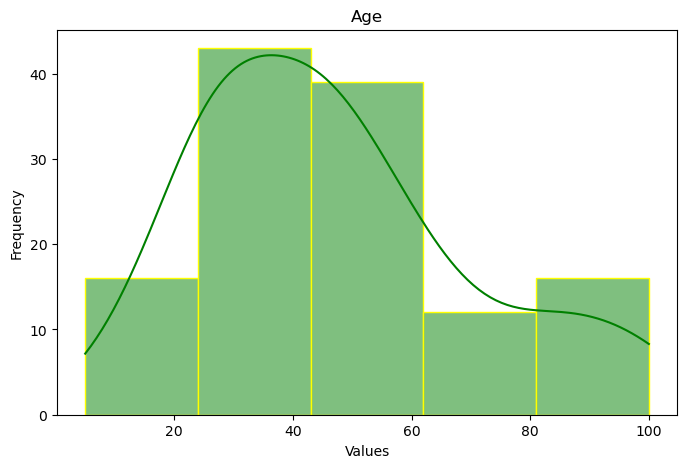

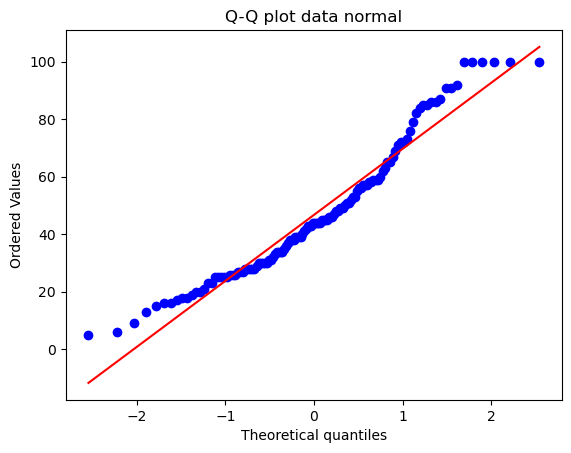

In [47]:
# Membuat histogram untuk melihat distribusi nilai umur
plt.figure(figsize=(8,5)) # Mengatur ukuran figure
sns.histplot(df['age'], bins=5, kde=True, color='green', edgecolor='yellow')  # bins = 5 artinya membagi umur menjadi 5 interval
plt.xlabel('Values')   # Label sumbu X
plt.ylabel('Frequency')  # Label sumbu Y
plt.title('Age')       # Judul histogram
plt.show()             # Menampilkan histogram

# Membuat Q-Q plot untuk memeriksa normalitas data umur
probplot(df["age"], dist="norm", plot=plt)  # Membandingkan distribusi umur dengan distribusi normal
plt.title("Q-Q plot data normal")  # Judul Q-Q plot
plt.show()  # Menampilkan Q-Q plot


Memeriksa normalisasi pada kolom `avg_glucose_level`dengan menggunakan histogram atau Q–Q plot (quantile-quantile plot)

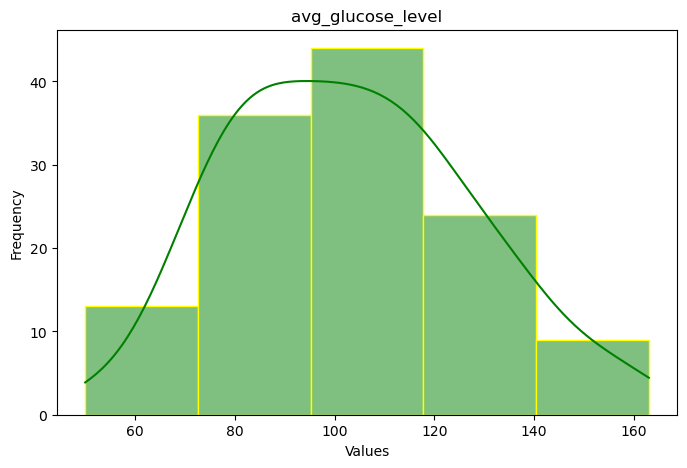

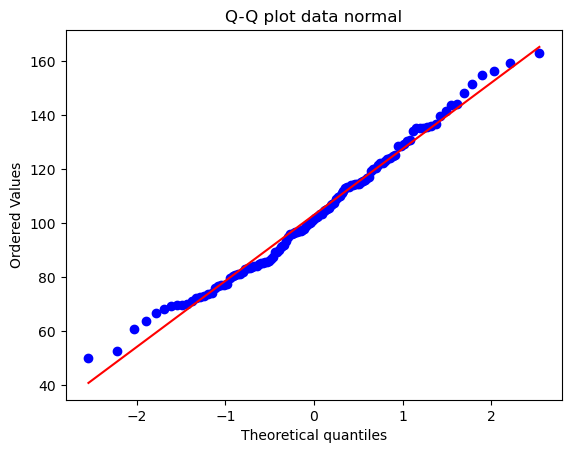

In [48]:
# Membuat histogram untuk melihat distribusi avg_glucose_level
plt.figure(figsize=(8,5)) #  Mengatur ukuran figure
sns.histplot(df['avg_glucose_level'], bins=5, kde=True, color='green', edgecolor='yellow') # bins=5 artinya membagi avg_glucose_level menjadi 5 interval
plt.xlabel('Values')   # Label sumbu X
plt.ylabel('Frequency')  # Label sumbu Y
plt.title('avg_glucose_level')       # Judul histogram
plt.show()             # Menampilkan histogram

# Membuat Q-Q plot untuk memeriksa normalitas avg_glucose_level
probplot(df["avg_glucose_level"], dist="norm", plot=plt)  # Membandingkan distribusi umur dengan distribusi normal
plt.title("Q-Q plot data normal")  # Judul Q-Q plot
plt.show()  # Menampilkan Q-Q plot


Memeriksa normalisasi pada kolom `BMI` dengan menggunakan histogram atau Q–Q plot (quantile-quantile plot)

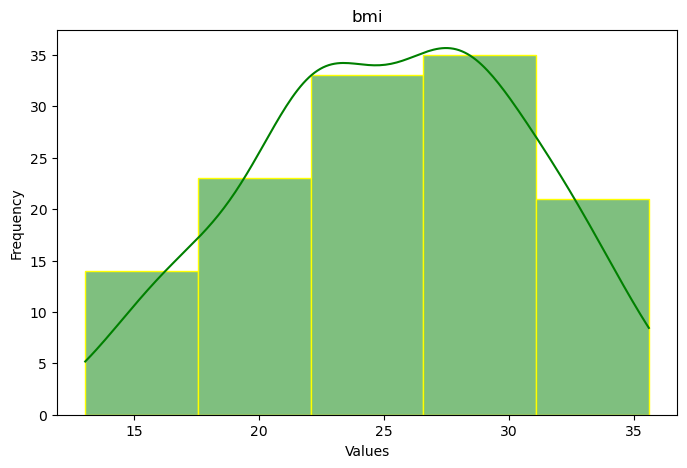

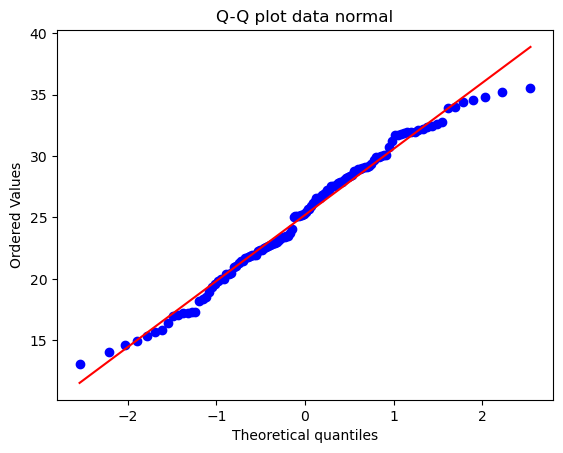

In [49]:
# Membuat histogram untuk melihat distribusi bmi
plt.figure(figsize=(8,5)) # Mengatur ukuran figure
sns.histplot(df['bmi'], bins=5, kde=True, color='green', edgecolor='yellow') # bins=5 artinya membagi bmi menjadi 5 interval
plt.xlabel('Values')   # Label sumbu X
plt.ylabel('Frequency')  # Label sumbu Y
plt.title('bmi')       # Judul histogram
plt.show()             # Menampilkan histogram

# Membuat Q-Q plot untuk memeriksa normalitas bmi
probplot(df["bmi"], dist="norm", plot=plt)  # Membandingkan distribusi bmi dengan distribusi normal
plt.title("Q-Q plot data normal")  # Judul Q-Q plot
plt.show()  # Menampilkan Q-Q plot


# Data Cleaning

## Memeriksa konsistensi data kategorikal

In [50]:
unique_data = df['gender'].unique()
print(unique_data)

['Male' 'Female']


In [51]:
unique_data1 = df['ever_married'].unique()
print(unique_data1)

['Yes' 'No']


In [52]:
unique_data2 = df['work_type'].unique()
print(unique_data2)

['Private' 'Self-employed' 'Never_worked' 'children' 'Govt_job']


pada kolom `work_type` terdapat inkonsistensi penulisan pada kategorikal, ada yang menggunakan huruf kapital diawal, dan ada yang tidak. Hal ini perlu diperbaiki agar semua kategori pada kolom tersebut konsisten dan memastikan keseragaman data sebelum melakukan analisis selanjutnya

In [53]:
unique_data3 = df['Residence_type'].unique()
print(unique_data3)

['Urban' 'Rural']


In [54]:
unique_data4 = df['smoking_status'].unique()
print(unique_data4)

['never smoked' 'formerly smoked' 'smokes' 'Unknown']


pada kolom `smoking_status` terdapat inkonsistensi penulisan pada kategorikal, ada yang menggunakan huruf kapital diawal, dan ada yang tidak. Hal ini perlu diperbaiki agar semua kategori pada kolom tersebut konsisten dan memastikan keseragaman data sebelum melakukan analisis selanjutnya

In [55]:
import pandas as pd

# 1. Atur agar kolom tidak dipotong (max width di-set ke None)
pd.set_option('display.max_colwidth', None)

list_info = []

for col in df.columns:
    list_info.append([
        col, 
        df[col].dtype, 
        df[col].nunique(), 
        list(df[col].unique())
    ])

df_info = pd.DataFrame(columns=['column', 'dtype', 'n_unique', 'unique_values'], data=list_info)

# 2. Tampilkan dataframe
display(df_info)

,column,dtype,n_unique,unique_values
0,id,int64,126,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, ...]"
1,gender,object,2,"[Male, Female]"
2,age,int64,65,"[44, 15, 55, 72, 38, 51, 45, 18, 71, 39, 59, 67, 28, 30, 32, 79, 21, 86, 46, 65, 42, 85, 87, 33, 20, 23, 69, 34, 50, 53, 26, 76, 27, 57, 91, 100, 31, 47, 48, 35, 56, 73, 63, 84, 58, 36, 43, 49, 41, 92, 25, 13, 6, 19, 16, 37, 52, 82, 60, 9, 29, 5, 62, 17, 40]"
3,hypertension,int64,2,"[1, 0]"
4,heart_disease,int64,2,"[0, 1]"
5,ever_married,object,2,"[Yes, No]"
6,work_type,object,5,"[Private, Self-employed, Never_worked, children, Govt_job]"
7,Residence_type,object,2,"[Urban, Rural]"
8,avg_glucose_level,float64,125,"[136.71, 77.12, 141.59, 128.37, 135.48, 97.04, 156.43, 60.68, 83.44, 111.7, 135.04, 119.83, 97.51, 85.75, 135.21, 122.93, 73.76, 72.87, 83.64, 79.79, 130.9, 113.07, 116.73, 105.75, 107.16, 52.55, 123.83, 83.1, 99.01, 85.8, 104.38, 117.19, 69.73, 107.58, 86.53, 139.64, 66.56, 69.92, 89.21, 72.23, 93.27, 84.16, 102.65, 130.24, 102.14, 104.87, 68.28, 95.98, 87.35, 120.45, 77.06, 74.18, 109.52, 159.4, 94.72, 105.05, 128.44, 115.3, 115.49, 97.14, 97.73, 77.35, 114.59, 113.91, 121.51, 85.36, 124.9, 134.0, 63.58, 91.09, 135.25, 80.51, 115.86, 100.26, 109.93, 101.17, 122.39, 69.35, 72.6, 143.94, 163.01, 99.84, 151.46, 76.85, 84.05, 143.72, 124.12, 148.19, 114.06, 69.62, 106.71, 136.06, 96.02, 91.41, 114.52, 83.21, 108.87, 101.91, 85.29, 129.42, ...]"
9,bmi,float64,121,"[29.1, 27.01, 22.63, 14.59, 28.36, 15.34, 18.17, 22.99, 18.93, 26.59, 23.52, 28.93, 16.96, 21.69, 25.02, 25.21, 28.47, 20.43, 22.66, 27.54, 14.01, 26.92, 28.82, 18.33, 23.42, 32.46, 28.3, 27.23, 29.95, 34.02, 25.09, 22.96, 29.94, 24.06, 20.36, 22.3, 26.56, 22.75, 23.13, 19.86, 32.18, 23.29, 21.44, 21.97, 29.01, 27.87, 22.49, 25.16, 26.38, 21.48, 17.3, 27.58, 21.76, 27.2, 26.61, 25.28, 22.87, 21.83, 19.31, 21.93, 27.84, 31.99, 31.26, 25.73, 23.47, 18.54, 34.6, 27.66, 17.33, 32.8, 21.28, 22.37, 30.11, 31.81, 20.0, 32.35, 29.37, 21.0, 23.77, 32.58, 17.2, 31.9, 29.23, 27.55, 25.66, 34.85, 35.59, 21.92, 28.06, 34.37, 21.07, 26.22, 30.02, 14.93, 29.14, 19.56, 25.96, 30.72, 13.05, 35.19, ...]"


## Memperbaiki inkonsistensi format

Memperbaiki inkonsistensi tersebut dengan cara mengubah kategorikal menggunakan huruf kapital diawal agar data lebih konsisten

Membuat data frame baru salinan dari df agar ketika digunakan untuk analisis tidak merusak data asli

In [56]:
df_clean = df.copy()

Memperbaiki kategorikal pada kolom `work_type`

In [57]:
df_clean['work_type'] = df_clean['work_type'].str.title()

Memperbaiki kategorikal pada kolom `smoking_status`

In [58]:
df_clean['smoking_status'] = df_clean['smoking_status'].str.title()

Memeriksa hasil perbaikan dari inkonsistensi data pada kolom `work_type`dan `smoking_status`

In [59]:
unique = df_clean['work_type'].unique()
print(unique)

['Private' 'Self-Employed' 'Never_Worked' 'Children' 'Govt_Job']


In [60]:
unique1 = df_clean['smoking_status'].unique()
print(unique1)

['Never Smoked' 'Formerly Smoked' 'Smokes' 'Unknown']


## Deteksi outlier menggunakan IQR

In [61]:
# kolom numerik
cols = ['age', 'avg_glucose_level', 'bmi']

# menghitung Q1, Q3, dan IQR
q1 = df_clean[cols].quantile(0.25)
q3 = df_clean[cols].quantile(0.75)
iqr = q3 - q1

# menghitung batas bawah dan atas
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Buat penanda outlier
mask = (df_clean[cols] < lower) | (df_clean[cols] > upper)

outliers = df_clean[mask.any(axis=1)] # Mengambil baris data yang mengandung outlier
outliers[cols] # menampilkan data

,age,avg_glucose_level,bmi


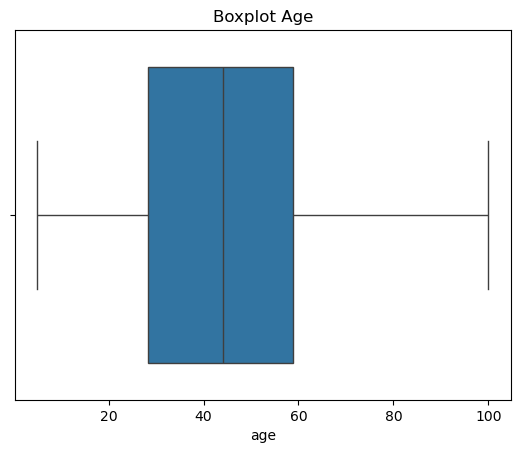

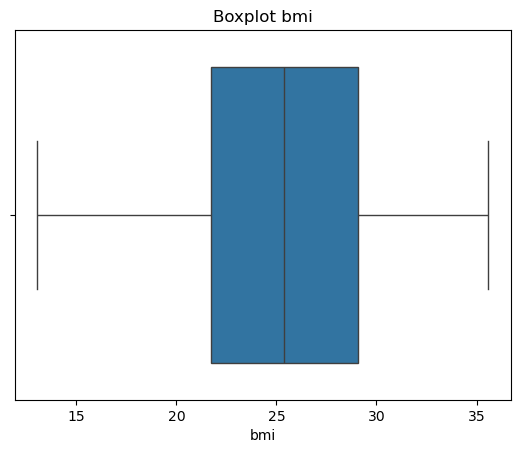

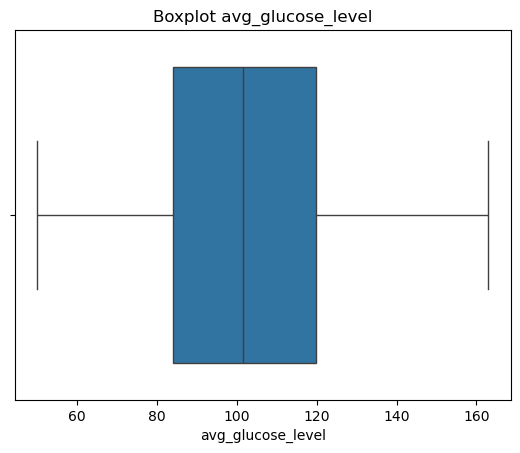

In [62]:
# Boxplot untuk kolom 'age'
sns.boxplot(x=df_clean['age']) 
plt.title("Boxplot Age")
plt.show()

# Boxplot untuk kolom 'bmi'
sns.boxplot(x=df_clean['bmi'])
plt.title("Boxplot bmi")
plt.show()

# Boxplot untuk kolom 'avg_glocose_level'
sns.boxplot(x=df_clean['avg_glucose_level'])
plt.title("Boxplot avg_glucose_level")
plt.show()

Deteksi outlier menggunakan IQR dan visualisasi box plot agar tidak menganggu proses analisis selanjutnya dan pada data ini tidak ditemukan nilai yang ekstrim

# Data Manipulation

## Menampilkan data type

In [63]:
df_clean.dtypes

id                     int64
gender                object
age                    int64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Pada kolom `gander`, `ever_married`, `work_type`, `Residence_typ`, `smoking_status` diubah menjadi type category

In [64]:
# mengubah data type object menjadi data type category
df_clean['gender'] = df_clean['gender'].astype('category')
df_clean['ever_married'] = df_clean['ever_married'].astype('category')
df_clean['work_type'] = df_clean['work_type'].astype('category')
df_clean['Residence_type'] = df_clean['Residence_type'].astype('category')
df_clean['smoking_status'] = df_clean['smoking_status'].astype('category')

Memeriksa kembali data type yang sudah diperbaiki

In [65]:
df_clean.dtypes

id                      int64
gender               category
age                     int64
hypertension            int64
heart_disease           int64
ever_married         category
work_type            category
Residence_type       category
avg_glucose_level     float64
bmi                   float64
smoking_status       category
stroke                  int64
dtype: object

## Analisis data menggunakan filtering dan sorting 

Memeriksa konsistensi kategori pada kolom `work_type` dan `age` karena terdapat beberapa pasien > 20 tahun termasuk kategori "Children"

In [66]:
# Filter usia < 20 tahun dan work_type bukan 'Children'
df_under20 = df_clean[(df_clean['age'] < 20) & (df_clean['work_type'] != 'Children')]

# Sorting berdasarkan umur (termuda → tertua)
df_under20 = df_under20.sort_values(by='age', ascending=True)

df_under20


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
115,116,Female,5,1,1,No,Self-Employed,Urban,122.39,26.84,Smokes,1
113,114,Female,9,1,0,No,Self-Employed,Urban,96.24,20.48,Never Smoked,0
1,2,Female,15,0,0,Yes,Self-Employed,Urban,77.12,27.01,Formerly Smoked,1
93,94,Female,16,0,0,No,Self-Employed,Rural,91.41,30.02,Never Smoked,1
100,101,Male,16,1,0,No,Self-Employed,Rural,119.38,28.93,Formerly Smoked,1
121,122,Female,17,0,0,No,Private,Urban,84.97,29.69,Smokes,0
35,36,Female,18,0,1,No,Self-Employed,Rural,139.64,22.30,Never Smoked,0
91,92,Female,19,0,0,No,Govt_Job,Rural,136.06,21.07,Smokes,0


Data dari satu data kemnaker Indonesia kelompok umur pencari kerja:
- Pada periode Januari - Juni 2023 10,58% berasal dari kelompok usia 11 – 20 tahun
- Pada priode Juli - Desember 2022 terdapat 11,43% berasal dari kelompok usia 11 – 20 tahun

Sumber https://www.bing.com/ck/a?!&&p=6265045ebe2ee95f3794ad14972979e9407f3ba20cfb2e97d725c87ce86e2554JmltdHM9MTc2ODAwMzIwMA&ptn=3&ver=2&hsh=4&fclid=120b6770-653b-6eae-1be8-77c8645e6f65&psq=statistik+bekerja+diumur+5+tahun+keatas+karena+tuntutan+ekonomi&u=a1aHR0cHM6Ly9zYXR1ZGF0YS5rZW1uYWtlci5nby5pZC9zYXR1ZGF0YS1wdWJsaWMvMjAyMy8xMi9maWxlcy9wdWJsaWthc2kvMTcwNDAzMDgzMDA0Nl8yMDIzJTI1MjAtJTI1MjBBbmFsaXNpcyUyNTIwUGFzYXIlMjUyMEtlcmphJTI1MjBEYWxhbSUyNTIwTmVnZXJpJTI1MjBUYWh1biUyNTIwMjAyMy5wZGY 

In [67]:
# Filter usia > 20 tahun dan work_type = 'Children'
df_children = df_clean[(df_clean['work_type'] == 'Children') & (df_clean['age'] > 19)]

# Sorting berdasarkan umur (termuda → tertua)
df_children = df_children.sort_values(by='age', ascending=True)

df_children

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
54,55,Female,23,0,0,No,Children,Urban,94.72,26.61,Never Smoked,0
97,98,Male,25,1,0,No,Children,Rural,101.91,25.96,Never Smoked,1
39,40,Male,26,1,0,No,Children,Urban,72.23,19.86,Unknown,0
81,82,Female,30,1,0,Yes,Children,Urban,99.84,17.20,Formerly Smoked,0
13,14,Male,30,0,0,No,Children,Rural,85.75,21.69,Formerly Smoked,0
112,113,Female,30,1,0,Yes,Children,Urban,71.31,25.17,Smokes,0
50,51,Female,31,1,0,Yes,Children,Urban,77.06,17.30,Smokes,0
69,70,Female,36,0,0,Yes,Children,Rural,91.09,17.33,Never Smoked,0
4,5,Male,38,1,0,No,Children,Rural,135.48,28.36,Smokes,0
9,10,Female,39,1,0,Yes,Children,Rural,111.70,26.59,Never Smoked,0


In [68]:
jumlah = len(df_children)
print("banyaknya data usia > 20 tahun dan termasuk kategori Children : ", jumlah)

banyaknya data usia > 20 tahun dan termasuk kategori Children :  29


Akibat terdapat inkonsistensi pada variable `work_type` khususnya pada kategori "children"
- Usia diatas 20 tahun pada data ini ada beberapa yang termasuk kategori "Children" sehingga kurang sesuai, ada sebanyak 29 data yang kurang sesuai
- Pada data ini juga terdapat usia dibawah 11 tahun masuk kategori bekerja

Penanganan data tidak sesuai dan inkonsisten :
- Untuk memastikan kategori agar konsisten, sesuai, dan tetap mempertahankan data asli akan dibuat kolom baru `final_work_type`.
- Pada kolom ini, usia diatas 20 tahun dengan kategori "children" diberi label "Unknown", dan usia dibawah 11 tahun. Sementara itu, data yang lain tidak berubah
- Karena berdasarkan data Kemnaker Indonesia, terdapat pencari kerja pada kelompok usia 11–20 tahun, sehingga kategori bekerja pada usia remaja masih dianggap sesuai

Membuat kolom baru `final_work_type`

In [69]:
df_clean['final_work_type'] = df_clean['work_type']

df_clean['final_work_type'] = df_clean['final_work_type'].cat.add_categories(['Unknown'])

df_clean.loc[(df_clean['age'] > 20) & (df_clean['work_type'] == 'Children'),'final_work_type'] = 'Unknown'

Memeriksa hasil penanganan

In [70]:
df_clean.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,final_work_type
0,1,Male,44,1,0,Yes,Private,Urban,136.71,29.10,Never Smoked,0,Private
1,2,Female,15,0,0,Yes,Self-Employed,Urban,77.12,27.01,Formerly Smoked,1,Self-Employed
2,3,Female,55,0,0,Yes,Never_Worked,Rural,141.59,22.63,Never Smoked,0,Never_Worked
3,4,Female,72,0,0,Yes,Never_Worked,Rural,128.37,14.59,Smokes,0,Never_Worked
4,5,Male,38,1,0,No,Children,Rural,135.48,28.36,Smokes,0,Unknown


Pasien usia < 20 dan memiliki stroke

In [71]:
# Filter pasien usia < 20 yang memiliki penyakit stroke
df_age_stroke = df_clean[(df_clean['age'] < 20) & (df_clean['stroke'] == 1)]

# Sorting berdasarkan age dari termuda ke tertua
df_age_stroke = df_age_stroke.sort_values(by='age', ascending=True)

# Tampilkan hasil
df_age_stroke 

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,final_work_type
115,116,Female,5,1,1,No,Self-Employed,Urban,122.39,26.84,Smokes,1,Self-Employed
89,90,Male,13,0,0,No,Children,Rural,69.62,28.06,Smokes,1,Children
1,2,Female,15,0,0,Yes,Self-Employed,Urban,77.12,27.01,Formerly Smoked,1,Self-Employed
93,94,Female,16,0,0,No,Self-Employed,Rural,91.41,30.02,Never Smoked,1,Self-Employed
100,101,Male,16,1,0,No,Self-Employed,Rural,119.38,28.93,Formerly Smoked,1,Self-Employed


- Hasil filtering dan sorting tersebut terdapat kasus data yang jarang ditemukan, dimana ada pasien perempuan yang berumur 5 tahun memiliki penyakit jantung dan hipertensi, Tidak hanya itu, anak tersebut memiliki gula darah yang sangat tinggi, bmi yang termasuk kategori "Overwhight", perokok aktif, dan memiliki penyakit stroke
- Menurut unicef pada tahun 2024 di Indonesia sekitar 18% usia anak dan remaja mulai 5 sampai 19 tahun mengalami kelebihan berat badan atau obesitas
- Survei Kesehatan Indonesia (SKI) 2023 dari Kementerian Kesehatan mengatakan sekitar 7,4% dari 70 juta perokok adalah anak-anak dan remaja berusia 10-18 tahun. Maka dari itu pada diatas terdapat usia belasan tahun yang pernah merokok atau perokok aktif
- Data Epidemiologi stroke pada anak terdapat sekitar 80% kasus penyakit stroke pada anak terjadi pada bayi dibawah usia 28 hari, kondisi tersebut adalah stroke perinatal yang disebabkan oleh penyumbatan aliran darah ke otak(arterial ischemic stroke). Anak usia diatas 28 hari hingga 18 tahun adalah childhood stroke yang disebabkan akibat penyumbatan pembuluh darah (stroke iskemik) dan pendarahan di otak (stroke hemoragik)
- Untuk pasien usia pasien belasan tahun mulai 13 tahun sampai 16 tahun, ada yang sudah bekerja, ada yang menikah dini, dan pada data diatas mayoritas memiliki penyakit gula darah yang tinggi dan overweight, dan memiliki penyakit stroke

Berdasarkan data dari unicef tahun 2023, sebanyak 25,53 juta perempuan menikah dibawah usia 18 tahun.

Merujuk pada Pasal 1 angka 26 UU Ketenagakerjaan

- Pemberi kerja dilarang memberikan pekerjaan kepada anak, usia minimal tenaga kerja di Indonesia adalah 18 tahun
- Ada sejumlah aturan anak berusia 13 tahun sampai 15 tahun boleh dipekerjakan untuk pekerjaan yang ringan dan tidak menganggu perkembangan kesehatan, fisik, mental, dan sosial anak tersebut

Sumber :
- Penyakit diabetes https://hellodoktor.com/kencing-manis/diabetes-jenis-dua/chart-paras-gula-dalam-darah/
- Statistik perokok pada anak dibawah umur tahun 2023 https://data.goodstats.id/statistic/perokok-di-indonesia-tembus-70-juta-orang-mayoritas-anak-muda-fYMeH
- Stroke pada anak https://www.alomedika.com/penyakit/neurologi/stroke-pada-anak/epidemiologi
- Kategori BMI https://www.alodokter.com/pemahaman-seputar-indeks-massa-tubuh
- Statistik obesitas pada anak dan remaja  https://www.bing.com/ck/a?!&&p=aa6b480f954a9964a71e36d7b1ee72203bcbfd020b78726fec9ba5e8afac8e68JmltdHM9MTc2ODAwMzIwMA&ptn=3&ver=2&hsh=4&fclid=120b6770-653b-6eae-1be8-77c8645e6f65&psq=obesitas+pada+usia+dibawah+20+tahun&u=a1aHR0cHM6Ly93d3cudW5pY2VmLm9yZy9pbmRvbmVzaWEvbWVkaWEvMjI0OTYvZmlsZS9BbmFsaXNpcyUyMExhbnNrYXAlMjBLZWxlYmloYW4lMjBCZXJhdCUyMEJhZGFuJTIwZGFuJTIwT2Jlc2l0YXMlMjBkaSUyMEluZG9uZXNpYTolMjBSaW5na2FzYW4lMjBUZW11YW4lMjBLdW5jaS5wZGY
- Pernikahan dini https://data.goodstats.id/statistic/ri-peringkat-4-jumlah-perempuan-yang-menikah-di-bawah-usia-18-tahun-JkHnB 

Ada beberapa faktor yang bisa menyebabkan stroke yaitu usia, jenis kelamin, keturunan, ras, hipertensi, hiperkolesterolemia, diabetes melitus, merokok, aterosklerosis, penyakit jantung, obesitas, konsumsi alkohol, stres, kondisi sosial ekonomi yang mendukung, diet yang tidak baik 

Sumber : Laily, S. R. (2017). Hubungan karakteristik penderita dan hipertensi dengan kejadian stroke iskemik. Jurnal berkala epidemiologi, 5(1), 48-59.
<br> https://e-journal.unair.ac.id/JBE/article/download/3142/2811

Pasien perempuan yang mengalami penyakit stroke

In [72]:
# Filter pasien hanya gender perempuanyang memiliki penyakit stroke
df_gender_stroke = df_clean[(df_clean['gender'] == 'Female') & (df_clean['stroke'] == 1)] 
# Sorting berdasarkan age dari termuda ke tertua
df_gender_stroke = df_gender_stroke.sort_values(by='age', ascending=True)
df_gender_stroke

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,final_work_type
115,116,Female,5,1,1,No,Self-Employed,Urban,122.39,26.84,Smokes,1,Self-Employed
1,2,Female,15,0,0,Yes,Self-Employed,Urban,77.12,27.01,Formerly Smoked,1,Self-Employed
93,94,Female,16,0,0,No,Self-Employed,Rural,91.41,30.02,Never Smoked,1,Self-Employed
30,31,Female,23,0,0,Yes,Govt_Job,Rural,104.38,25.09,Formerly Smoked,1,Govt_Job
45,46,Female,27,1,0,No,Self-Employed,Rural,104.87,27.87,Unknown,1,Self-Employed
51,52,Female,47,1,0,Yes,Private,Urban,74.18,27.58,Never Smoked,1,Private
52,53,Female,48,1,0,Yes,Children,Urban,109.52,21.76,Never Smoked,1,Unknown
95,96,Female,58,1,0,Yes,Children,Urban,83.21,29.14,Smokes,1,Unknown
92,93,Female,59,1,0,Yes,Self-Employed,Urban,96.02,26.22,Unknown,1,Self-Employed
107,108,Female,60,0,1,Yes,Govt_Job,Urban,81.28,30.12,Formerly Smoked,1,Govt_Job


In [73]:
banyak = len(df_gender_stroke) # menghitung banyaknya pasien perempuan yang mengalami stroke
print("Pada data ini pasien perempuan yang mengalami penyakit stroke adalah : ", banyak)

Pada data ini pasien perempuan yang mengalami penyakit stroke adalah :  20


Tidak hanya dewasa dan lansia yang memiliki penyakit stroke, tetapi usia anak dan remaja juga bisa mengalami stroke. Mayoritas pasien memiliki penyakit hipertensi, dan sudah menikah

Pasien laki-laki yang mengalami penyakit stroke

In [74]:
# Filter pasien hanya gender perempuanyang memiliki penyakit stroke
df_gender_stroke1 = df_clean[(df_clean['gender'] == 'Male') & (df_clean['stroke'] == 1)] 
# Sorting berdasarkan age dari termuda ke tertua
df_gender_stroke1 = df_gender_stroke1.sort_values(by='age', ascending=True)
df_gender_stroke1

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,final_work_type
89,90,Male,13,0,0,No,Children,Rural,69.62,28.06,Smokes,1,Children
100,101,Male,16,1,0,No,Self-Employed,Rural,119.38,28.93,Formerly Smoked,1,Self-Employed
97,98,Male,25,1,0,No,Children,Rural,101.91,25.96,Never Smoked,1,Unknown
40,41,Male,28,1,0,Yes,Self-Employed,Rural,93.27,32.18,Never Smoked,1,Self-Employed
58,59,Male,45,1,1,Yes,Never_Worked,Urban,115.49,19.31,Smokes,1,Never_Worked
36,37,Male,50,1,0,Yes,Children,Urban,66.56,26.56,Formerly Smoked,1,Unknown
117,118,Male,51,1,0,Yes,Govt_Job,Urban,96.69,25.09,Formerly Smoked,1,Govt_Job
66,67,Male,53,1,0,Yes,Private,Urban,124.90,18.54,Unknown,1,Private
63,64,Male,56,1,1,Yes,Children,Urban,113.91,25.73,Never Smoked,1,Unknown
64,65,Male,73,1,1,Yes,Children,Urban,121.51,31.99,Never Smoked,1,Unknown


In [75]:
banyak1 = len(df_gender_stroke1) # menghitung banyaknya pasien laki-laki yang mengalami stroke
print("Pada data ini pasien laki-laki yang mengalami penyakit stroke adalah : ", banyak1)

Pada data ini pasien laki-laki yang mengalami penyakit stroke adalah :  18


Tidak hanya dewasa dan lansia yang memiliki penyakit stroke, tetapi remaja juga bisa mengalami stroke. Mayoritas pasien memiliki penyakit hipertensi, dan sudah menikah

Pasien perempuan yang tidak mengalami penyakit stroke

In [76]:
# Filter pasien hanya gender perempuan yang tidak memiliki penyakit stroke
df_gender_stroke3 = df_clean[(df_clean['gender'] == 'Female') & (df_clean['stroke'] == 0)] 
# Sorting berdasarkan age dari termuda ke tertua
df_gender_stroke3 = df_gender_stroke3.sort_values(by='age', ascending=True)
df_gender_stroke3

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,final_work_type
113,114,Female,9,1,0,No,Self-Employed,Urban,96.24,20.48,Never Smoked,0,Self-Employed
121,122,Female,17,0,0,No,Private,Urban,84.97,29.69,Smokes,0,Private
7,8,Female,18,0,0,Yes,Children,Rural,60.68,22.99,Formerly Smoked,0,Children
35,36,Female,18,0,1,No,Self-Employed,Rural,139.64,22.30,Never Smoked,0,Self-Employed
91,92,Female,19,0,0,No,Govt_Job,Rural,136.06,21.07,Smokes,0,Govt_Job
118,119,Female,20,1,0,No,Never_Worked,Urban,81.24,22.92,Never Smoked,0,Never_Worked
54,55,Female,23,0,0,No,Children,Urban,94.72,26.61,Never Smoked,0,Unknown
41,42,Female,26,0,0,No,Self-Employed,Rural,84.16,23.29,Never Smoked,0,Self-Employed
12,13,Female,28,1,0,No,Govt_Job,Urban,97.51,16.96,Never Smoked,0,Govt_Job
114,115,Female,29,0,0,Yes,Self-Employed,Urban,81.93,23.41,Smokes,0,Self-Employed


In [77]:
banyak3 = len(df_gender_stroke3) # menghitung banyaknya pasien perempuan yang tidak mengalami stroke
print("Pada data ini pasien perempuan yang tidak mengalami penyakit stroke adalah : ", banyak3)

Pada data ini pasien perempuan yang tidak mengalami penyakit stroke adalah :  42


Pasien perempuan yang tidak memiliki penyakit stroke adalah mayoritas tidak memiliki penyakit hipertensi, jantung, dan tidak merokok. Untuk bmi dan kadar gula darah beberapa pasien terdapat yang normal dan lebih diatas normal

Pasien laki-laki yang tidak mengalami penyakit stroke

In [78]:
# Filter pasien hanya gender laki-laki yang tidak memiliki penyakit stroke
df_gender_stroke4 = df_clean[(df_clean['gender'] == 'Male') & (df_clean['stroke'] == 0)] 
# Sorting berdasarkan age dari termuda ke tertua
df_gender_stroke4 = df_gender_stroke4.sort_values(by='age', ascending=True)
df_gender_stroke4

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,final_work_type
90,91,Male,6,1,0,No,Children,Rural,106.71,34.37,Formerly Smoked,0,Children
29,30,Male,20,0,0,Yes,Private,Rural,85.80,34.02,Formerly Smoked,0,Private
16,17,Male,21,0,0,No,Self-Employed,Rural,73.76,28.47,Never Smoked,0,Self-Employed
125,126,Male,25,1,1,No,Never_Worked,Rural,125.11,33.93,Smokes,0,Never_Worked
111,112,Male,25,0,0,No,Never_Worked,Rural,111.20,31.96,Never Smoked,0,Never_Worked
108,109,Male,25,0,0,Yes,Private,Urban,103.45,28.19,Unknown,0,Private
84,85,Male,25,0,0,Yes,Never_Worked,Rural,84.05,27.55,Never Smoked,0,Never_Worked
49,50,Male,26,0,0,No,Self-Employed,Rural,120.45,21.48,Never Smoked,0,Self-Employed
39,40,Male,26,1,0,No,Children,Urban,72.23,19.86,Unknown,0,Unknown
85,86,Male,27,1,0,No,Private,Rural,143.72,25.66,Never Smoked,0,Private


In [79]:
banyak4 = len(df_gender_stroke4) # menghitung banyaknya pasien laki-laki yang tidak mengalami stroke
print("Pada data ini pasien laki-laki yang tidak mengalami penyakit stroke adalah : ", banyak4)

Pada data ini pasien laki-laki yang tidak mengalami penyakit stroke adalah :  46


Pada data ini, pasien laki-laki yang tidak memiliki penyakit stroke adalah mayoritas tidak merokok dan tidak memiliki penyakit jantung, masih ditemukan pasien dengan BMI dan kadar gula darah di atas normal. hampir setengah dari jumlah pasien memiliki penyakit hipertensi

## Analisis data menggunakan grouping

Pengelompokan data berdasarkan jenis kelamin dan status stroke

In [80]:
# Melakukan pengelompokan data berdasarkan jenis kelamin dan status stroke
# observed=True digunakan agar kategori yang ada di data yang ditampilkan
xy = df_clean.groupby(["gender", "stroke"],observed=True)["id"].nunique()  # Menghitung jumlah unik pasien (id) pada setiap kelompok
xy #menampilkan hasil

gender  stroke
Female  0         42
        1         20
Male    0         46
        1         18
Name: id, dtype: int64

Pada data ini, pada pasien laki-laki lebih banyak yang tidak memiliki penyakit stroke daripada pasien perempuan

Pengelompokan data berdasarkan penyakit hipertensi dan status stroke

In [81]:
# Melakukan pengelompokan data berdasarkan penyakit hipertensi dan status stroke
# observed=True digunakan agar kategori yang ada di data yang ditampilkan
ab = df_clean.groupby(["hypertension", "stroke"],observed=True)["id"].nunique()  # Menghitung jumlah unik pasien (id) pada setiap kelompok
ab #menampilkan hasil

hypertension  stroke
0             0         57
              1          7
1             0         31
              1         31
Name: id, dtype: int64

Mayoritas pasien yang tidak memiliki penyakit hipertensi tidak juga mengalami stroke. Penyakit hipertensi merupakan salah satu faktor penyebab penyakit stroke

Pengelompokan data berdasarkan penyakit heart disease dan status stroke

In [82]:
# Melakukan pengelompokan data berdasarkan penyakit heart_disease dan status stroke
# observed=True digunakan agar kategori yang ada di data yang ditampilkan
cd = df_clean.groupby(["heart_disease", "stroke"],observed=True)["id"].nunique()  # Menghitung jumlah unik pasien (id) pada setiap kelompok
cd#menampilkan hasil

heart_disease  stroke
0              0         82
               1         28
1              0          6
               1         10
Name: id, dtype: int64

Mayoritas pasien yang tidak memiliki penyakit jantung tidak mengalami stroke. Penyakit jantung merupakan salah satu faktor penyebab penyakit stroke

Pengelompokan data berdasarkan usia, bmi, kadar gula darah dan status stroke

In [83]:
# Mengelompokkan data berdasarkan status stroke
# Menghitung nilai rata-rata usia, BMI, dan kadar gula darah pada tiap kelompok stroke
group_mean = df_clean.groupby("stroke",observed=True)[["age", "bmi", "avg_glucose_level"]].mean()
group_mean

,age,bmi,avg_glucose_level
stroke,,,
0,40.602273,24.776932,103.131364
1,60.894737,26.208158,102.736842


Pasien yang memiliki penyakit stroke rata-rata berumur 60 tahun dengan bmi termasuk kategori overweigt meskipun perbedaan yang tidak terlalu jauh antara pasien yang memiliki penyakit stroke dan tidak , dan rata-rata kadar gula darah yang lebih dari normal memiliki penyakit stroke meskipun perbedaannya tidak terlalu jauh dengan pasien yang tidak memiliki penyakit stroke

- Terdapat penelitian dari Universitas Airlangga tahun 2020, bahwa obesitas berisiko terkena penyakit stroke iskemik
Sumber : https://unair.ac.id/obesitas-lebih-berisiko-terkena-stroke-iskemik/ <br>
- Gula darah yang tinggi juga berisiko terkena penyakit stroke
Sumber : https://www.alodokter.com/benarkah-diabetes-bisa-mengakibatkan-stroke

Walaupun pada dataset ini memiliki perbedaan yang tidak terlalu jauh. Tetapi, sesuai dengan referensi atau sumber sebelumnya yang menunjukkan obesitas dan kadar gula darah tinggi dapat meningkatkan risiko stroke.

Pengelompokan data berdasarkan status pernikahan dan status stroke

In [84]:
# Menghitung jumlah tiap kategori ever_married berdasarkan status stroke
df_clean.groupby("stroke", observed=True)["ever_married"].value_counts()

stroke  ever_married
0       Yes             56
        No              32
1       Yes             32
        No               6
Name: count, dtype: int64

Pasien yang sudah menikah mayoritas tidak memiliki penyakit stroke. Terdapat penelitian dari Duke University di North Carolina, membuktikan orang yang tidak menikah berisiko memiliki penyakit stroke 71% lebih tinggi dari yang sudah menikah. Penelitian ini juga mengatakan perceraian yang sebelumnya sudah pernah menikah juga dapat meningkatkan risiko memiliki penyakit stroke hingga 25%. Kesimpulan dari penelitian tersebut adalah menikah bisa bahagaia karena seperti memiliki teman hidup, teman berbagi, dan teman yang saling mendukung, sehingga kondisi mental lebih baik

sumber : https://pmc.ncbi.nlm.nih.gov/articles/PMC5210404/#jah31889-sec-0014 dan <br>
https://www.klikdokter.com/info-sehat/saraf/benarkah-menikah-bisa-cegah-stroke

Pengelompokan data berdasarkan tempat tinggal dan status stroke

Jenis tempat tinggal pasien :
1. rural = daerah pedesaan
2. urban = daerah perkotaan

In [85]:
# Menghitung jumlah tiap kategori ever_married berdasarkan status stroke
df_clean.groupby("stroke", observed=True)["Residence_type"].value_counts()

stroke  Residence_type
0       Rural             45
        Urban             43
1       Urban             21
        Rural             17
Name: count, dtype: int64

Tidak jauh beda antara distribusi rural dan urban yang tidak memiliki penyakit stroke. Sedangkan yang memiliki penyakit stroke sedikit lebih banyak urban daripada rural. seperti pada penelitian yang dilakukan oleh universitas airlangga pada tahun 2024, mereka membuktikan komunitas urban memiliki risiko stroke lebih tinggi dibanding rural. Penyebabnya karena faktor lingkungan dan gaya hidup 

sumber : 
- https://scholar.unair.ac.id/en/publications/stroke-risk-factors-based-on-the-framingham-stroke-risk-score-amo/?_gl=1*155abu7*_gcl_au*NDU4MDU5NjA1LjE3NjgxMjg4NjY.*_ga*NTYxNjMxNDU1LjE3Njc2MjExODk.*_ga_WKCGRN02BK*czE3NjgxMjg4NjYkbzEkZzEkdDE3NjgxMjk0NzMkajYwJGwwJGgw
- https://unair.ac.id/faktor-risiko-stroke-pada-populasi-urban-dan-rural/

Pengelompokan data berdasarkan kebiasaan merokok pasien dan status stroke

In [86]:
# Menghitung jumlah tiap kategori ever_married berdasarkan status stroke
df_clean.groupby("stroke", observed=True)["smoking_status"].value_counts()

stroke  smoking_status 
0       Never Smoked       53
        Unknown            13
        Formerly Smoked    11
        Smokes             11
1       Never Smoked       15
        Formerly Smoked     8
        Unknown             8
        Smokes              7
Name: count, dtype: int64

Mayoritas pasien yang tidak memiliki penyakit stroke adalah tidak merokok. Meskipun banyak pasien stroke yang tidak merokok. Terdapat penelitian yang dilakukan oleh Universitas Malahayati pada tahun 2024 membuktikan bahwa perokok berisiko memiliki penyakit stroke dua sampai empat kali lipat pada pria dan wanita. Maka dari itu, pentingnya memperhatikan faktor risiko lain selain kebiasaan merokok

sumber : Istiana, N. S., Putri, P. H., Kurniati, M., & Amroisa, R. A. N. (2024). Sebaran Kebiasaan Merokok Pada Pasien Stroke Iskemik Di Rumah Sakit Pertamina Bintang Amin. Jurnal Medika Malahayati, 8(4), 948-955. <br>
https://ejurnalmalahayati.ac.id/index.php/medika/article/view/18644

Pengelompokan data berdasarkan jenis pekerjaan pasien dan status stroke

Jenis pekerjaan pasien :
1. private = karyawan swasta
2. self-employed = wiraswasta/pengusaha
3. never_worked = tidak pernah bekerja
4. govt_job = PNS
5. children = anak-anak (belum bekerja)

In [87]:
# Menghitung jumlah tiap kategori ever_married berdasarkan status stroke
df_clean.groupby("stroke", observed=True)["work_type"].value_counts()

stroke  work_type    
0       Never_Worked     21
        Children         19
        Private          19
        Self-Employed    16
        Govt_Job         13
1       Children         13
        Self-Employed    11
        Govt_Job          6
        Private           5
        Never_Worked      3
Name: count, dtype: int64

Pada data ini, stroke terjadi hampir semua jenis pekerjaan. Mayoritas pasien yang tidak bekerja banyak yang tidak memiliki penyakit stroke. Sedangkan kategori 'unknown'yang belum diketahui jenis pekerjaannya memiliki penyakit stroke paling tinggi. 

## Membuat kolom baru

Membuat kolom `glucose_category` dari kolom `avg_glucose_level`

In [88]:
# Membuat kategori glukosa 
df_clean['glucose_category'] = df_clean['avg_glucose_level'].apply(lambda x: 'Low' if x < 70 else ('Normal' if 70 <= x <= 100 else ('Prediabetes' if 101 <= x <= 125 else 'Diabetes')))

# Lihat hasil beberapa baris
df_clean[['avg_glucose_level', 'glucose_category']].head()

,avg_glucose_level,glucose_category
0,136.71,Diabetes
1,77.12,Normal
2,141.59,Diabetes
3,128.37,Diabetes
4,135.48,Diabetes


Membuat kolom `bmi_category` dari kolom `bmi`

In [89]:
# Membuat kategori BMI 
df_clean['bmi_category'] = df_clean['bmi'].apply(lambda x: 'Underweight' if x <= 18.49 else ('Normal' if 18.5 <= x <= 24.9 else ('Overweight' if 25 <= x <= 29.9 else 'Obese')))

# Lihat hasil beberapa baris
df_clean[['bmi', 'bmi_category']].head()

,bmi,bmi_category
0,29.10,Overweight
1,27.01,Overweight
2,22.63,Normal
3,14.59,Underweight
4,28.36,Overweight


Membuat kolom `age_category` dari kolom `age`

In [90]:
# Membuat kategori usia
df_clean['age_category'] = df_clean['age'].apply(lambda x: 'Children' if x <= 10 else ('Teenager' if 11 <= x <= 19 else ('Adult' if 20 <= x <= 64 else 'Elderly')))

# Lihat hasil beberapa baris
df_clean[['age','age_category']].head(10)

,age,age_category
0,44,Adult
1,15,Teenager
2,55,Adult
3,72,Elderly
4,38,Adult
5,51,Adult
6,45,Adult
7,18,Teenager
8,71,Elderly
9,39,Adult


# Output final dataset

Menampilkan data yang belum siap dianalisis

In [91]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,Male,44,1,0,Yes,Private,Urban,136.71,29.10,never smoked,0
1,2,Female,15,0,0,Yes,Self-employed,Urban,77.12,27.01,formerly smoked,1
2,3,Female,55,0,0,Yes,Never_worked,Rural,141.59,22.63,never smoked,0
3,4,Female,72,0,0,Yes,Never_worked,Rural,128.37,14.59,smokes,0
4,5,Male,38,1,0,No,children,Rural,135.48,28.36,smokes,0


Menampilkan data yang sudah siap dianalisis

In [92]:
df_clean.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,final_work_type,glucose_category,bmi_category,age_category
0,1,Male,44,1,0,Yes,Private,Urban,136.71,29.10,Never Smoked,0,Private,Diabetes,Overweight,Adult
1,2,Female,15,0,0,Yes,Self-Employed,Urban,77.12,27.01,Formerly Smoked,1,Self-Employed,Normal,Overweight,Teenager
2,3,Female,55,0,0,Yes,Never_Worked,Rural,141.59,22.63,Never Smoked,0,Never_Worked,Diabetes,Normal,Adult
3,4,Female,72,0,0,Yes,Never_Worked,Rural,128.37,14.59,Smokes,0,Never_Worked,Diabetes,Underweight,Elderly
4,5,Male,38,1,0,No,Children,Rural,135.48,28.36,Smokes,0,Unknown,Diabetes,Overweight,Adult


Pada data yang digunakan tidak memiliki missing value, outlier, dan data duplikat. Selanjutnya, dilakukan perbaikan tipe data agar sesuai dengan jenis setiap kolom dan memperbaiki format penulisan agar konsisten.
Selain itu, dibuat kolom baru `final_work_type` untuk memperbaiki kategori pekerjaan yang tidak sesuai, misalnya pasien berumur > 20 tahun yang sebelumnya masuk kategori Children pada kolom `work_type` sehingga diperbaiki menjadi "Unknown"

## Encoding

Komputer tidak langsung paham tentang data kategorikal sehingga perlu dilakukan yang namanya mengubah data kategorikal menjadi angka numerik atau bisa disebut encoding

In [93]:
df_raw = df_clean.copy()

Pada kolom `age_category` menggunakan metode ordinal encoding karena memiliki urutan

In [94]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['Adult', 'Children','Teenager','Elderly',]])

df_raw['age_category'] = encoder.fit_transform(df_raw[['age_category']]).astype(int)

df_raw.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,final_work_type,glucose_category,bmi_category,age_category
0,1,Male,44,1,0,Yes,Private,Urban,136.71,29.10,Never Smoked,0,Private,Diabetes,Overweight,0
1,2,Female,15,0,0,Yes,Self-Employed,Urban,77.12,27.01,Formerly Smoked,1,Self-Employed,Normal,Overweight,2
2,3,Female,55,0,0,Yes,Never_Worked,Rural,141.59,22.63,Never Smoked,0,Never_Worked,Diabetes,Normal,0
3,4,Female,72,0,0,Yes,Never_Worked,Rural,128.37,14.59,Smokes,0,Never_Worked,Diabetes,Underweight,3
4,5,Male,38,1,0,No,Children,Rural,135.48,28.36,Smokes,0,Unknown,Diabetes,Overweight,0


Kolom kategorikal lainnya menggunakan label encoder karena tidak memiliki urutan

In [95]:
encoding = [   # kolom kategorikal yang akan di encoding
    'gender',
    'work_type',
    'Residence_type',
    'smoking_status',
    'final_work_type',
    'glucose_category',
    'ever_married'
]


label_encoders = {} # Membuat dictionary untuk menyimpan objek LabelEncoder untuk tiap kolom

for col in encoding:
    le = LabelEncoder() # Membuat instance LabelEncoder baru
    df_raw[col] = le.fit_transform(df_raw[col])
    label_encoders[col] = le   # Menyimpan LabelEncoder di dictionary supaya bisa memeriksa mapping label seperti kategori label 1 itu apa


In [96]:
non_encoding = [
    'id',
    'age',
    'hypertension',
    'heart_disease',
    'avg_glucose_level',
    'bmi',
    'stroke'
]

Menampilkan hasl encoding dan non encoding

In [97]:
df_final = df_raw[non_encoding + encoding +['age_category']]
df_final.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender,work_type,Residence_type,smoking_status,final_work_type,glucose_category,ever_married,age_category
0,1,44,1,0,136.71,29.10,0,1,3,1,1,3,0,1,0
1,2,15,0,0,77.12,27.01,1,0,4,1,0,4,2,1,2
2,3,55,0,0,141.59,22.63,0,0,2,0,1,2,0,1,0
3,4,72,0,0,128.37,14.59,0,0,2,0,2,2,0,1,3
4,5,38,1,0,135.48,28.36,0,1,0,0,2,5,0,0,0


Menampilkan keterangan hasil encoding

In [98]:
for col, le in label_encoders.items():
    print(f"\nKolom: {col}") # Menampilkan nama kolom yang sedang dicek
    label_mapping = pd.DataFrame({ # Membuat tabel dataframe untuk melihat mapping antara angka hasil labeling dan kategori asli
        'Label': le.transform(le.classes_), # Mengubah kategori asli ke angka sesuai encoder
        'Kategori_Asli': le.classes_  # Menampilkan kategori asli 
    })
    print(label_mapping)



Kolom: gender
   Label Kategori_Asli
0      0        Female
1      1          Male

Kolom: work_type
   Label  Kategori_Asli
0      0       Children
1      1       Govt_Job
2      2   Never_Worked
3      3        Private
4      4  Self-Employed

Kolom: Residence_type
   Label Kategori_Asli
0      0         Rural
1      1         Urban

Kolom: smoking_status
   Label    Kategori_Asli
0      0  Formerly Smoked
1      1     Never Smoked
2      2           Smokes
3      3          Unknown

Kolom: final_work_type
   Label  Kategori_Asli
0      0       Children
1      1       Govt_Job
2      2   Never_Worked
3      3        Private
4      4  Self-Employed
5      5        Unknown

Kolom: glucose_category
   Label Kategori_Asli
0      0      Diabetes
1      1           Low
2      2        Normal
3      3   Prediabetes

Kolom: ever_married
   Label Kategori_Asli
0      0            No
1      1           Yes


In [99]:
age_mapping = pd.DataFrame({ # Membuat daftar angka encoding
    'Kode_Encoding': range(len(encoder.categories_[0])), # Jumlah kode disesuaikan dengan banyaknya kategori age_category
    'Kategori_Asli': encoder.categories_[0]    # Mengambil daftar kategori asli age_category dan urutannya sesuai dengan yang ditentukan pada OrdinalEncoder
})

print("Kolom: age_category")
print(age_mapping)

Kolom: age_category
   Kode_Encoding Kategori_Asli
0              0         Adult
1              1      Children
2              2      Teenager
3              3       Elderly


Kemudian sertakan pendapat kalian terhadap hasil yang didapat dari eksplorasi

- Pada data yang digunakan tidak memiliki missing value, outlier, dan data duplikat.
- Perbaikan tipe data agar sesuai dengan jenis setiap kolom dan memperbaiki format penulisan agar konsisten.
- Selain itu, dibuat kolom baru `final_work_type` untuk memperbaiki kategori pekerjaan yang tidak sesuai, misalnya pasien berumur > 20 tahun yang sebelumnya masuk kategori Children pada kolom `work_type` sehingga diperbaiki menjadi "Unknown".
-  Terdapat kasus data yang jarang ditemukan, dimana ada pasien perempuan yang berumur 5 tahun memiliki penyakit jantung dan hipertensi, Tidak hanya itu, anak tersebut memiliki gula darah yang sangat tinggi, bmi yang termasuk kategori "Overwhight", perokok aktif, dan memiliki penyakit stroke

| Atribut           | Keterangan                                                                                                                                                                                                             | Tipe Data |
| ----------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------- |
| id                | Nomor identitas untuk setiap pasien                                                                                                                                                                                    | int    |
| gender            | Jenis kelamin pasien                                                                                                                                                                                                   | category  |
| age               | Usia pasien                                                                                                                                                                                                            | int     |
| hypertension      | Pasien yang memiliki penyakit tekanan darah tinggi (1), dan tidak (0)                                                                                                                                                  | category  |
| heart_disease     | Pasien yang memiliki penyakit jantung (1), dan tidak (0)                                                                                                                                                               | category  |
| ever_married      | Pasien pernah atau sedang menikah ("Yes"), tidak ("No")                                                                                                                                                                | category  |
| work_type         | Jenis pekerjaan pasien: <br> 1. private = karyawan swasta <br> 2. self-employed = wiraswasta/pengusaha <br> 3. never_worked = tidak pernah bekerja <br> 4. govt_job = PNS <br> 5. children = anak-anak (belum bekerja) | category  |
| residence_type    | Jenis tempat tinggal pasien: <br> 1. rural = daerah pedesaan <br> 2. urban = daerah perkotaan                                                                                                                          | category  |
| avg_glucose_level | Rata-rata kadar gula dalam darah pasien                                                                                                                                                                                | float  |
| bmi               | Indeks massa tubuh pasien                                                                                                                                                                                              | float   |
| smoking_status    | Kebiasaan merokok pasien: <br> 1. never smoked = tidak pernah merokok <br> 2. formerly smoked = pernah merokok tetapi sudah berhenti <br> 3. smokes = masih merokok <br> 4. unknown = belum diketahui                  | category  |
| stroke            | Pasien yang pernah mengalami penyakit stroke (1), dan tidak (0)                                                                                                                                                        | category  |


# EDA

## Heatmap

Melihat hubungan korelasi antar variable

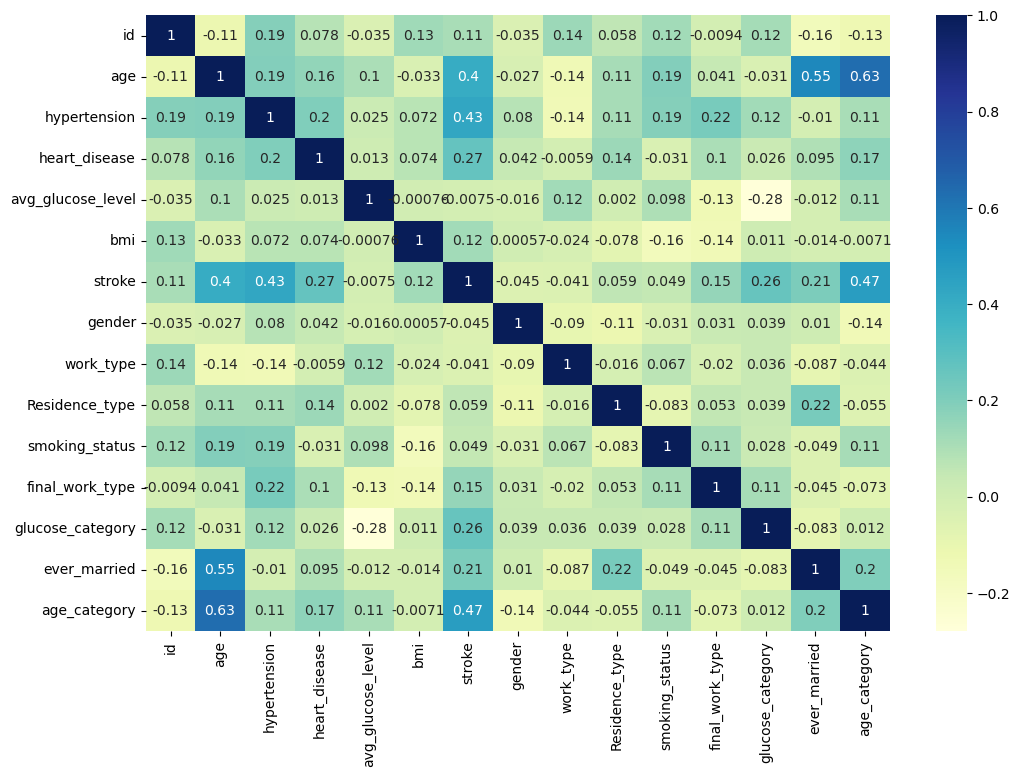

In [100]:
plt.figure(figsize=(12, 8))

# Hitung matriks korelasi
co_mtx = df_final.corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Menampilkan heatmap
plt.show()

Perbandingan gender

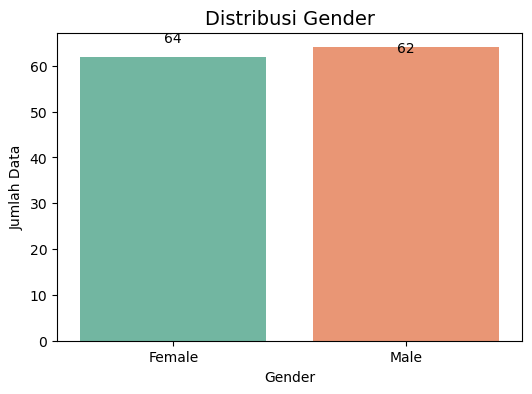

In [101]:
# Mengatur ukuran grafik agar proporsional dan mudah dibaca
plt.figure(figsize=(6,4))

# Membuat bar chart distribusi gender
ax = sns.countplot(
    data=df_clean,     # Dataset hasil cleaning
    x="gender",        # Sumbu X: kategori gender
    hue="gender",      # Digunakan agar legend otomatis muncul
    palette="Set2"     # Palet warna untuk membedakan kategori
)

# Memberi judul grafik
plt.title("Distribusi Gender", fontsize=14)

# Memberi label sumbu X dan Y
plt.xlabel("Gender")
plt.ylabel("Jumlah Data")

# Menghitung jumlah data untuk setiap gender
gender_counts = df_clean["gender"].value_counts()

# Menambahkan anotasi jumlah di atas setiap bar
for i, v in enumerate(gender_counts):
    ax.text(i, v + 1, v, ha='center')

# Menampilkan grafik
plt.show()

Pada data ini, jumlah female dan male dapat dikatakan relatif seimbang karena kedua gender tersebut memiliki rentang jumlah yang tidak jauh

Presentase kasus pasien stroke

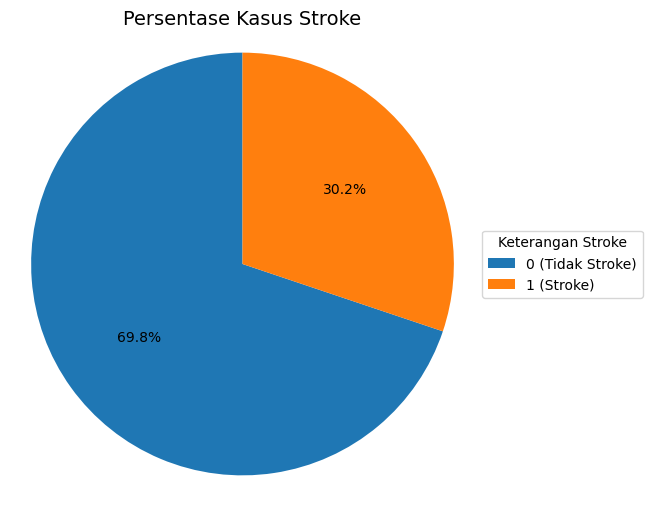

In [102]:
# Menghitung jumlah data berdasarkan nilai stroke (0 dan 1)
stroke_counts = df_clean["stroke"].value_counts().sort_index()

# Label untuk legend sesuai nilai asli data
legend_labels = ["0 (Tidak Stroke)", "1 (Stroke)"]

# Mengatur ukuran grafik
plt.figure(figsize=(6,6))

# Membuat pie chart tanpa label langsung di irisan
wedges, texts, autotexts = plt.pie(
    stroke_counts,
    autopct='%1.1f%%',   # Menampilkan persentase
    startangle=90        # Memulai dari posisi atas
)

# Menambahkan legend untuk menjelaskan arti setiap irisan
plt.legend(
    wedges,              # Objek irisan pie chart yang akan diberi keterangan legend
    legend_labels,       # Teks label untuk setiap irisan (0 = Tidak Stroke, 1 = Stroke)
    title="Keterangan Stroke",  # Judul pada legend untuk menjelaskan isi kategori
    loc="center left",   # Posisi legend relatif terhadap grafik (tengah kiri)
    bbox_to_anchor=(1, 0.5)  # Menggeser legend ke luar grafik agar tidak menutupi pie
)


# Memberi judul grafik
plt.title("Persentase Kasus Stroke", fontsize=14)

# Menjaga pie tetap berbentuk lingkaran
plt.axis('equal')

# Menampilkan grafik
plt.show()

Pada data ini, menunjukkan bahwa terdapat 30.2% pasien yang mengalami stroke, sedangkan 69.8% mayoritas pasien tidak mengalami stroke

### Jumlah status stroke

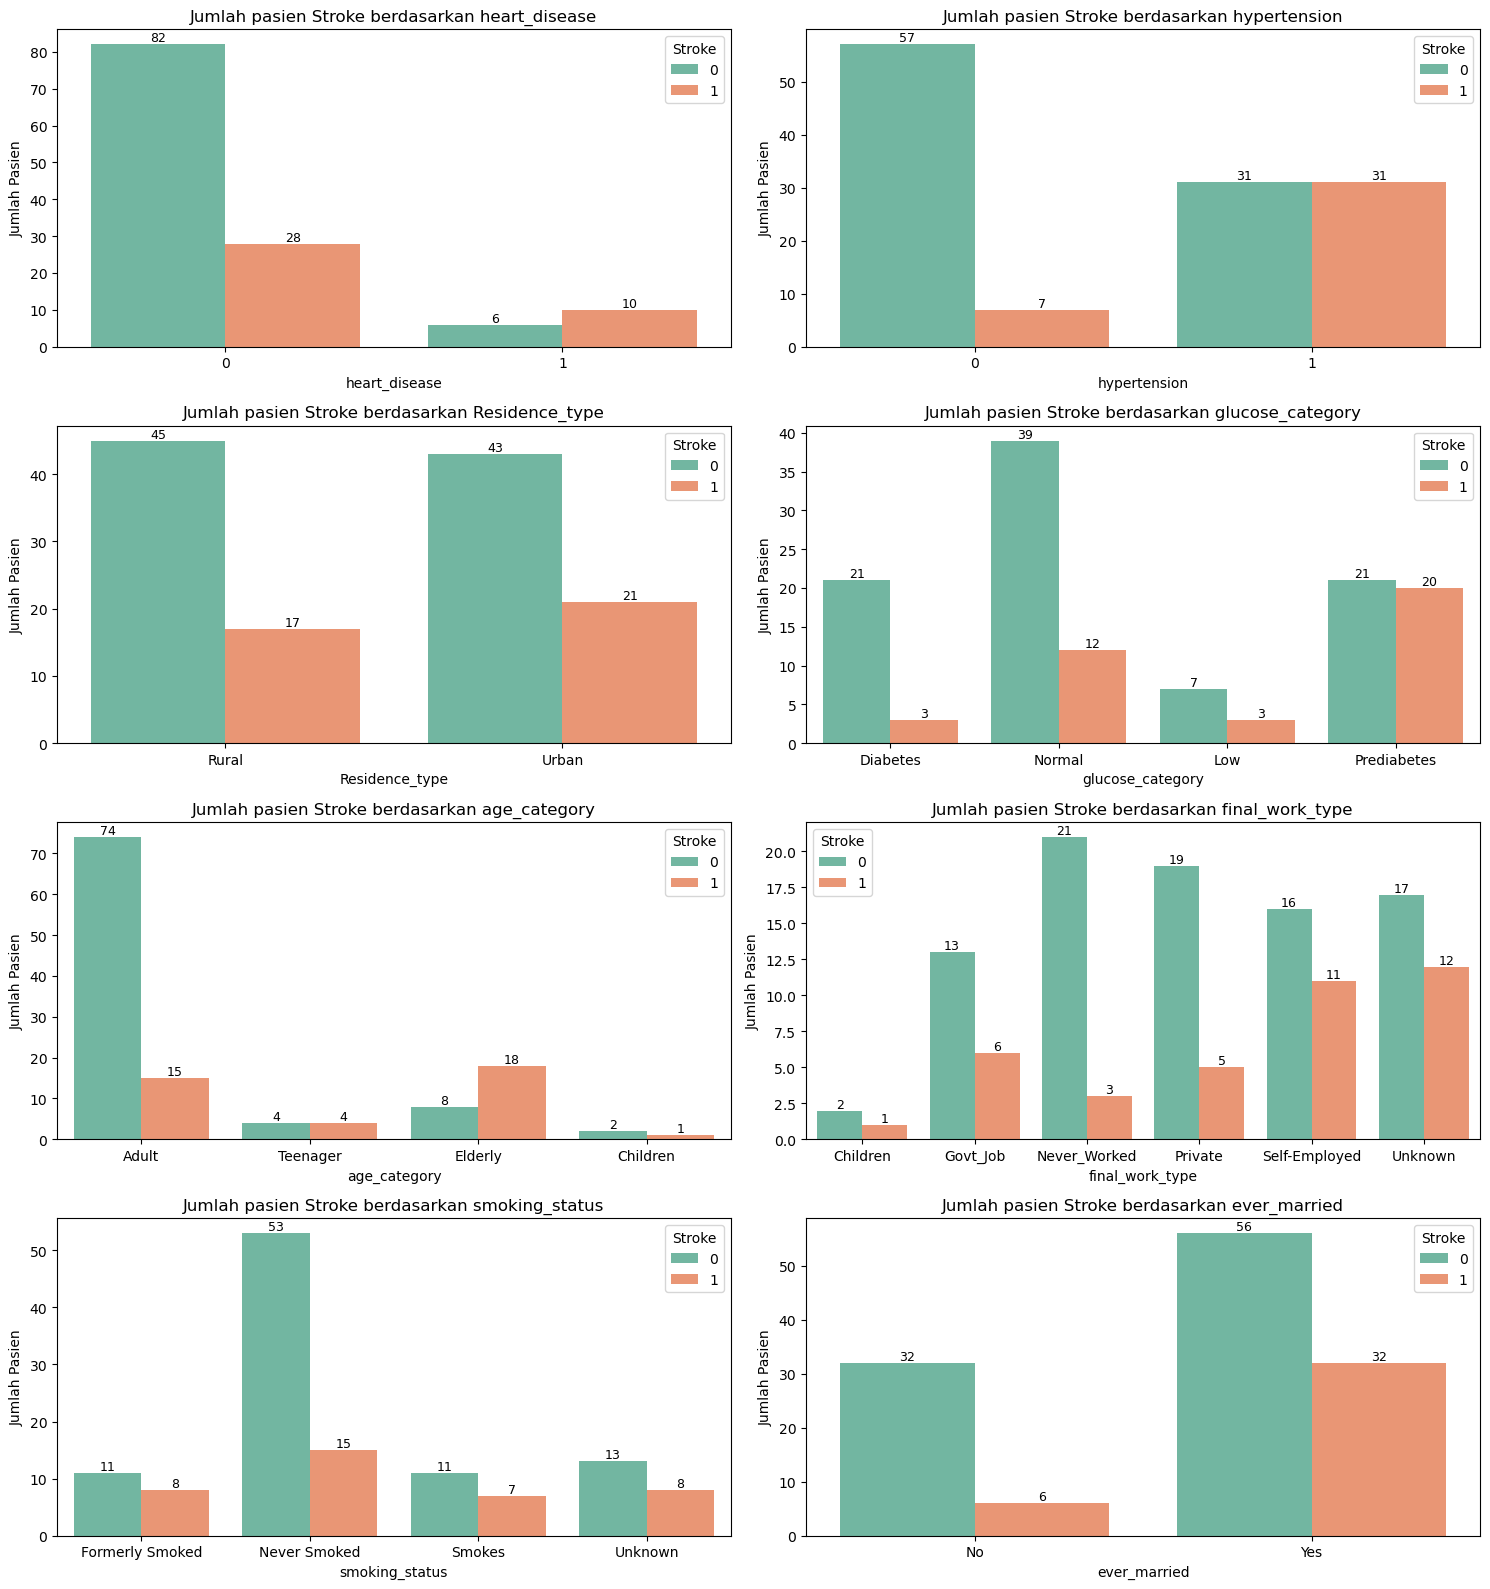

In [103]:
# Daftar variabel kategorikal yang akan dianalisis
# Setiap variabel akan dibandingkan dengan status stroke
categorical_cols = [
    'heart_disease', 
    'hypertension', 
    'Residence_type', 
    'glucose_category', 
    'age_category', 
    'final_work_type', 
    'smoking_status',
    'ever_married'
]


# Menentukan jumlah kolom subplot dalam satu baris
# Dalam hal ini, setiap baris terdiri dari 2 grafik
n_cols = 2


# Menghitung jumlah baris subplot secara otomatis
# Rumus ini memastikan semua variabel masuk ke dalam grid
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols


# Membuat figure dan kumpulan subplot sesuai jumlah baris dan kolom
# figsize diatur agar grafik tetap jelas dan tidak terlalu rapat
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))


# Mengubah axes menjadi array 1 dimensi agar mudah di-loop
axes = axes.flatten()


# Loop untuk membuat countplot pada setiap variabel kategorikal
for i, col in enumerate(categorical_cols):

    # Membuat bar chart jumlah pasien berdasarkan kategori
    # x       : variabel kategorikal
    # hue     : membedakan pasien stroke (1) dan tidak stroke (0)
    # palette : menentukan skema warna grafik
    # ax      : menentukan posisi subplot
    sns.countplot(
        data=df_clean,
        x=col,
        hue='stroke',
        palette='Set2',
        ax=axes[i]
    )

    # Memberikan judul pada setiap subplot
    axes[i].set_title(f"Jumlah pasien Stroke berdasarkan {col}")

    # Memberikan label pada sumbu X
    axes[i].set_xlabel(col)

    # Memberikan label pada sumbu Y
    axes[i].set_ylabel("Jumlah Pasien")

    # Menampilkan legenda untuk membedakan stroke dan tidak stroke
    axes[i].legend(title="Stroke")


    # Menambahkan anotasi berupa jumlah pasien di atas setiap batang
    # Anotasi hanya ditampilkan jika tinggi batang lebih dari 0
    # Hal ini untuk menghindari munculnya angka 0 pada grafik
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:
            axes[i].annotate(
                f'{int(height)}',                       # Teks anotasi
                (p.get_x() + p.get_width() / 2, height),# Posisi anotasi
                ha='center',                            # Posisi horizontal teks
                va='bottom',                            # Posisi vertikal teks
                fontsize=9                              # Ukuran font
            )


# Menghapus subplot kosong jika jumlah variabel tidak memenuhi grid
# Ini dilakukan agar tampilan grafik tetap rapi
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


# Mengatur jarak antar subplot agar tidak saling bertumpuk
plt.tight_layout()


# Menampilkan seluruh grafik
plt.show()


| Visualisasi | Interpretasi |
|------------|--------------|
| Jumlah pasien stroke berdasarkan **heart disease (penyakit jantung)** | Pasien yang tidak memiliki penyakit jantung memiliki jumlah kasus stroke yang lebih rendah, sedangkan pasien dengan penyakit jantung menunjukkan proporsi stroke yang lebih tinggi, sehingga penyakit jantung menjadi salah satu faktor risiko stroke. |
| Jumlah pasien stroke berdasarkan **hypertension (hipertensi)** | Pada pasien yang tidak memiliki hipertensi, kasus stroke relatif rendah. Sebaliknya, pasien dengan hipertensi menunjukkan jumlah kasus stroke yang lebih tinggi, sehingga hipertensi berperan sebagai faktor risiko stroke. |
| Jumlah pasien stroke berdasarkan **residence type (jenis tempat tinggal)** | Jumlah pasien stroke di wilayah Urban lebih tinggi dibandingkan Rural, namun perbedaannya tidak terlalu ekstrem. Hal ini menunjukkan bahwa jenis tempat tinggal memiliki pengaruh, tetapi bukan faktor dominan. |
| Jumlah pasien stroke berdasarkan **glucose category (kategori kadar gula darah)** | Pasien dengan kategori prediabetes dan diabetes memiliki jumlah kasus stroke yang lebih tinggi dibandingkan kategori low. Kategori normal tetap memiliki kasus stroke karena jumlah populasinya lebih besar. |
| Jumlah pasien stroke berdasarkan **age category (kategori usia)** | Semakin bertambah usia, jumlah dan risiko terjadinya stroke semakin meningkat, dengan kategori lansia (elderly) menunjukkan kasus stroke tertinggi. |
| Jumlah pasien stroke berdasarkan **final work type (jenis pekerjaan)** | Jenis pekerjaan dapat memengaruhi kesehatan, di mana faktor seperti tingkat stres, jam kerja, dan aktivitas fisik berpotensi meningkatkan risiko stroke pada kelompok pekerjaan tertentu. |
| Jumlah pasien stroke berdasarkan **smoking status (kebiasaan merokok)** | Pasien yang tidak pernah merokok memiliki jumlah kasus stroke yang lebih rendah, sementara pasien dengan riwayat merokok menunjukkan jumlah kasus stroke yang lebih tinggi, sehingga kebiasaan merokok berkaitan dengan risiko stroke. |
| Jumlah pasien stroke berdasarkan **status menikah**| Terdapat penelitian dari Duke University di North Carolina, membuktikan orang yang tidak menikah berisiko memiliki penyakit stroke 71% lebih tinggi dari yang sudah menikah|


Jumlah pasien stroke berdasarkan gender

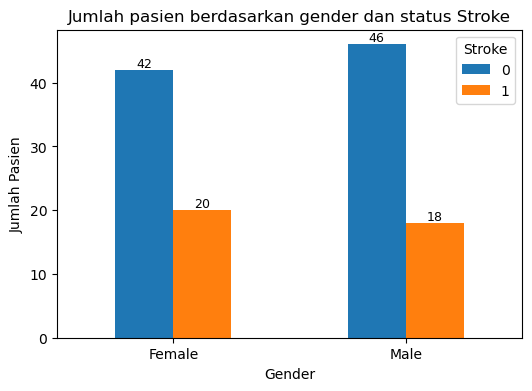

In [104]:
# Mengubah hasil groupby menjadi format tabel (kolom) agar mudah divisualisasikan
xy = df_clean.groupby(["gender", "stroke"], observed=True)["id"].nunique().unstack() # menggunakan unstack() agar lebih rapi bar chartnya tidak terpisah

# Membuat bar chart
ax = xy.plot(kind="bar", figsize=(6,4))

# Memberi judul dan label sumbu
plt.title("Jumlah pasien berdasarkan gender dan status Stroke")
plt.xlabel("Gender")
plt.ylabel("Jumlah Pasien")
plt.xticks(rotation=0)
plt.legend(title="Stroke")

# Menambahkan anotasi nilai di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=9)

plt.show()

Pada data ini, perempuan lebih banyak yang memiliki penyakit stroke, namun perbedaannya tidak terlalu ekstrem.

### Pairplot

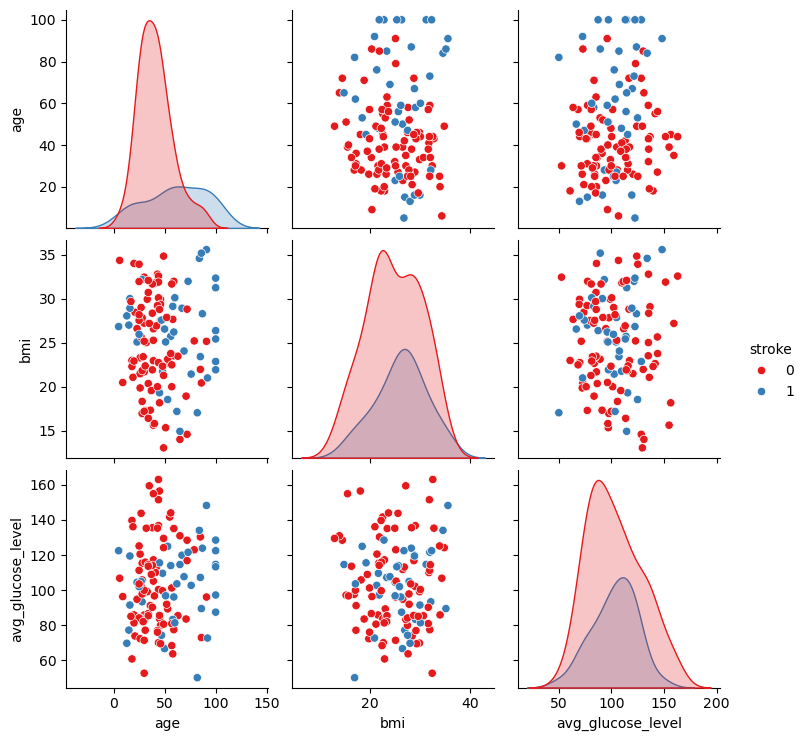

In [105]:
sns.pairplot(
    df_clean,
    vars=["age", "bmi", "avg_glucose_level"],
    hue="stroke",
    palette="Set1",
    diag_kind="kde"
)
plt.show()


Analisis ini bertujuan untuk melihat pola dan kecenderungan faktor usia, BMI, serta kadar gula darah pada pasien stroke dan tidak stroke :
- Kasus stroke lebih banyak ditemukan pada kelompok usia yang lebih tua.
- Nilai BMI pada pasien stroke dan non-stroke memiliki pola yang hampir sama, sehingga tidak terlihat perbedaan yang jelas.
- Nilai kadar gula darah pada pasien stroke dan non-stroke juga cenderung mirip, sehingga belum terlihat batas yang tegas antara keduanya.

### Jantung

Sumber :
- Hubungan penyakit jantung dan stroke
https://www.siloamhospitals.com/informasi-siloam/artikel/hubungan-penyakit-jantung-dengan-stroke

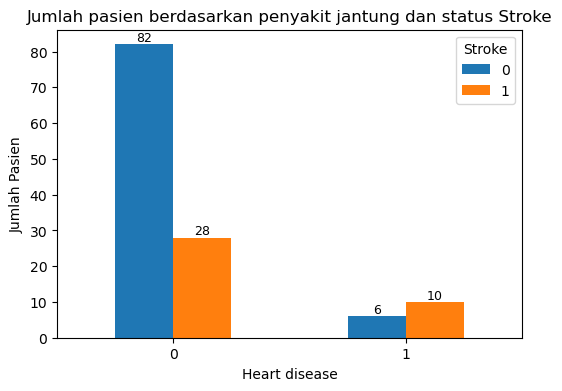

In [106]:
# Mengubah hasil groupby menjadi format tabel (kolom) agar mudah divisualisasikan
xy = df_clean.groupby(["heart_disease", "stroke"], observed=True)["id"].nunique().unstack() # menggunakan unstack() agar lebih rapi bar chartnya tidak terpisah

# Membuat bar chart
ax = xy.plot(kind="bar", figsize=(6,4))

# Memberi judul dan label sumbu
plt.title("Jumlah pasien berdasarkan penyakit jantung dan status Stroke")
plt.xlabel("Heart disease")
plt.ylabel("Jumlah Pasien")
plt.xticks(rotation=0)
plt.legend(title="Stroke")

# Menambahkan anotasi nilai di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=9)

plt.show()

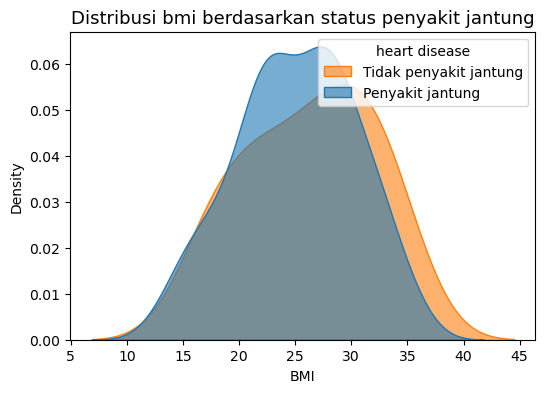

In [107]:
# Mengatur ukuran grafik agar mudah dibaca
plt.figure(figsize=(6,4))

# Membuat density plot (KDE) dengan hue
sns.kdeplot(
    data=df_clean,               # Dataset hasil cleaning
    x="bmi",       # Variabel numerik (kontinu)
    hue="heart_disease",                # Pembeda kategori (0 = Tidak, 1 = Ya)
    fill=True,                   # Mengisi area density
    common_norm=False,           # Normalisasi terpisah tiap kelompok
    alpha=0.6                    # Transparansi agar tidak saling menutupi
)

# Memberi judul grafik
plt.title(
    "Distribusi bmi berdasarkan status penyakit jantung",
    fontsize=13
)

# Memberi label sumbu X dan Y
plt.xlabel("BMI")
plt.ylabel("Density")

# Mengatur legend agar informatif
plt.legend(
    title="heart disease",
    labels=["Tidak penyakit jantung", "Penyakit jantung"],
    loc="upper right"
)

# Menampilkan grafik
plt.show()


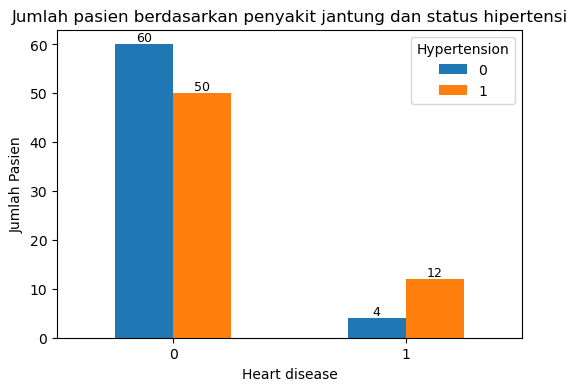

In [108]:
# Mengubah hasil groupby menjadi format tabel (kolom) agar mudah divisualisasikan
xy = df_clean.groupby(["heart_disease", "hypertension"], observed=True)["id"].nunique().unstack() # menggunakan unstack() agar lebih rapi bar chartnya tidak terpisah

# Membuat bar chart
ax = xy.plot(kind="bar", figsize=(6,4))

# Memberi judul dan label sumbu
plt.title("Jumlah pasien berdasarkan penyakit jantung dan status hipertensi")
plt.xlabel("Heart disease")
plt.ylabel("Jumlah Pasien")
plt.xticks(rotation=0)
plt.legend(title="Hypertension")

# Menambahkan anotasi nilai di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=9)

plt.show()

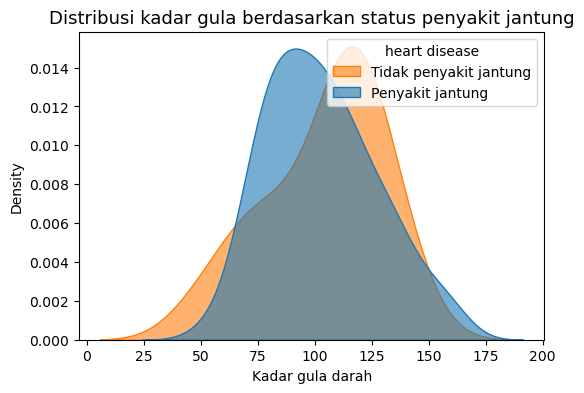

In [109]:
# Mengatur ukuran grafik agar mudah dibaca
plt.figure(figsize=(6,4))

# Membuat density plot (KDE) dengan hue
sns.kdeplot(
    data=df_clean,               # Dataset hasil cleaning
    x="avg_glucose_level",       # Variabel numerik (kontinu)
    hue="heart_disease",                # Pembeda kategori (0 = Tidak, 1 = Ya)
    fill=True,                   # Mengisi area density
    common_norm=False,           # Normalisasi terpisah tiap kelompok
    alpha=0.6                    # Transparansi agar tidak saling menutupi
)

# Memberi judul grafik
plt.title(
    "Distribusi kadar gula berdasarkan status penyakit jantung",
    fontsize=13
)

# Memberi label sumbu X dan Y
plt.xlabel("Kadar gula darah")
plt.ylabel("Density")

# Mengatur legend agar informatif
plt.legend(
    title="heart disease",
    labels=["Tidak penyakit jantung", "Penyakit jantung"],
    loc="upper right"
)

# Menampilkan grafik
plt.show()


kadar gula dalam darah yang tinggi dapat menyebabkan kerusakan pada lapisan pembuluh darah bagian dalam dan berakibat pada menurunnya suplai darah ke otot jantung dan otak. Seiring waktu, kondisi ini dapat mengakibatkan seseorang rentan terkena serangan jantung, stroke, dan penyakit pembuluh darah perifer. 

- Artikel Siloam Hospitals https://www.siloamhospitals.com/informasi-siloam/artikel/hubungan-diabetes-dengan-penyakit-jantung
- Artikel Kementrian kesehatan : https://keslan.kemkes.go.id/view_artikel/2272/diabetes-dan-penyakit-jantung


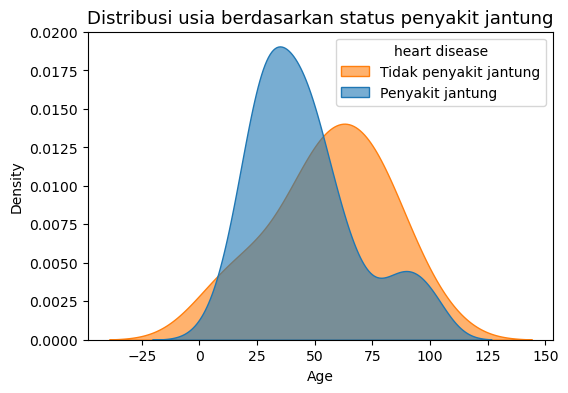

In [110]:
# Mengatur ukuran grafik agar mudah dibaca
plt.figure(figsize=(6,4))

# Membuat density plot (KDE) dengan hue
sns.kdeplot(
    data=df_clean,               # Dataset hasil cleaning
    x="age",       # Variabel numerik (kontinu)
    hue="heart_disease",                # Pembeda kategori (0 = Tidak, 1 = Ya)
    fill=True,                   # Mengisi area density
    common_norm=False,           # Normalisasi terpisah tiap kelompok
    alpha=0.6                    # Transparansi agar tidak saling menutupi
)

# Memberi judul grafik
plt.title(
    "Distribusi usia berdasarkan status penyakit jantung",
    fontsize=13
)

# Memberi label sumbu X dan Y
plt.xlabel("Age")
plt.ylabel("Density")

# Mengatur legend agar informatif
plt.legend(
    title="heart disease",
    labels=["Tidak penyakit jantung", "Penyakit jantung"],
    loc="upper right"
)

# Menampilkan grafik
plt.show()


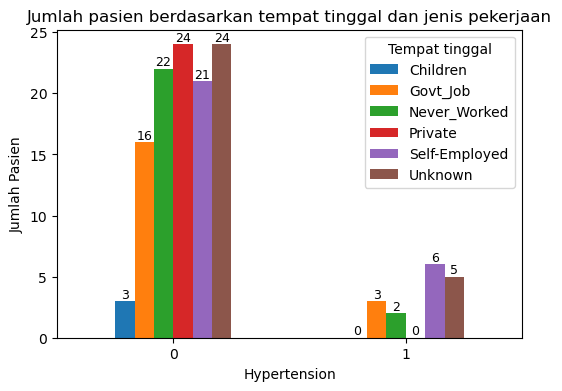

In [111]:
# Mengubah hasil groupby menjadi format tabel (kolom) agar mudah divisualisasikan
xy = df_clean.groupby(["heart_disease", "final_work_type"], observed=True)["id"].nunique().unstack() # menggunakan unstack() agar lebih rapi bar chartnya tidak terpisah

# Membuat bar chart
ax = xy.plot(kind="bar", figsize=(6,4))

# Memberi judul dan label sumbu
plt.title("Jumlah pasien berdasarkan tempat tinggal dan jenis pekerjaan")
plt.xlabel("Hypertension")
plt.ylabel("Jumlah Pasien")
plt.xticks(rotation=0)
plt.legend(title="Tempat tinggal")

# Menambahkan anotasi nilai di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=9)

plt.show()

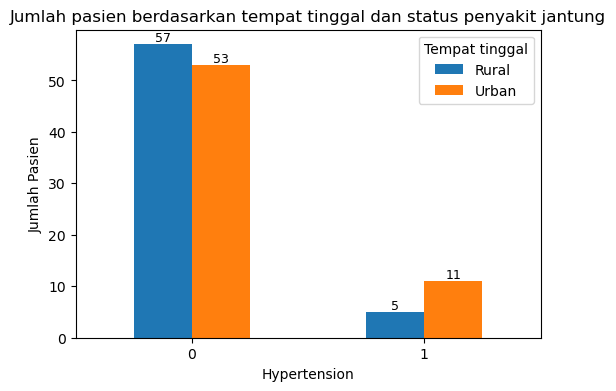

In [112]:
# Mengubah hasil groupby menjadi format tabel (kolom) agar mudah divisualisasikan
xy = df_clean.groupby(["heart_disease", "Residence_type"], observed=True)["id"].nunique().unstack() # menggunakan unstack() agar lebih rapi bar chartnya tidak terpisah

# Membuat bar chart
ax = xy.plot(kind="bar", figsize=(6,4))

# Memberi judul dan label sumbu
plt.title("Jumlah pasien berdasarkan tempat tinggal dan status penyakit jantung")
plt.xlabel("Hypertension")
plt.ylabel("Jumlah Pasien")
plt.xticks(rotation=0)
plt.legend(title="Tempat tinggal")

# Menambahkan anotasi nilai di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=9)

plt.show()

Menggabungkan visualisasi

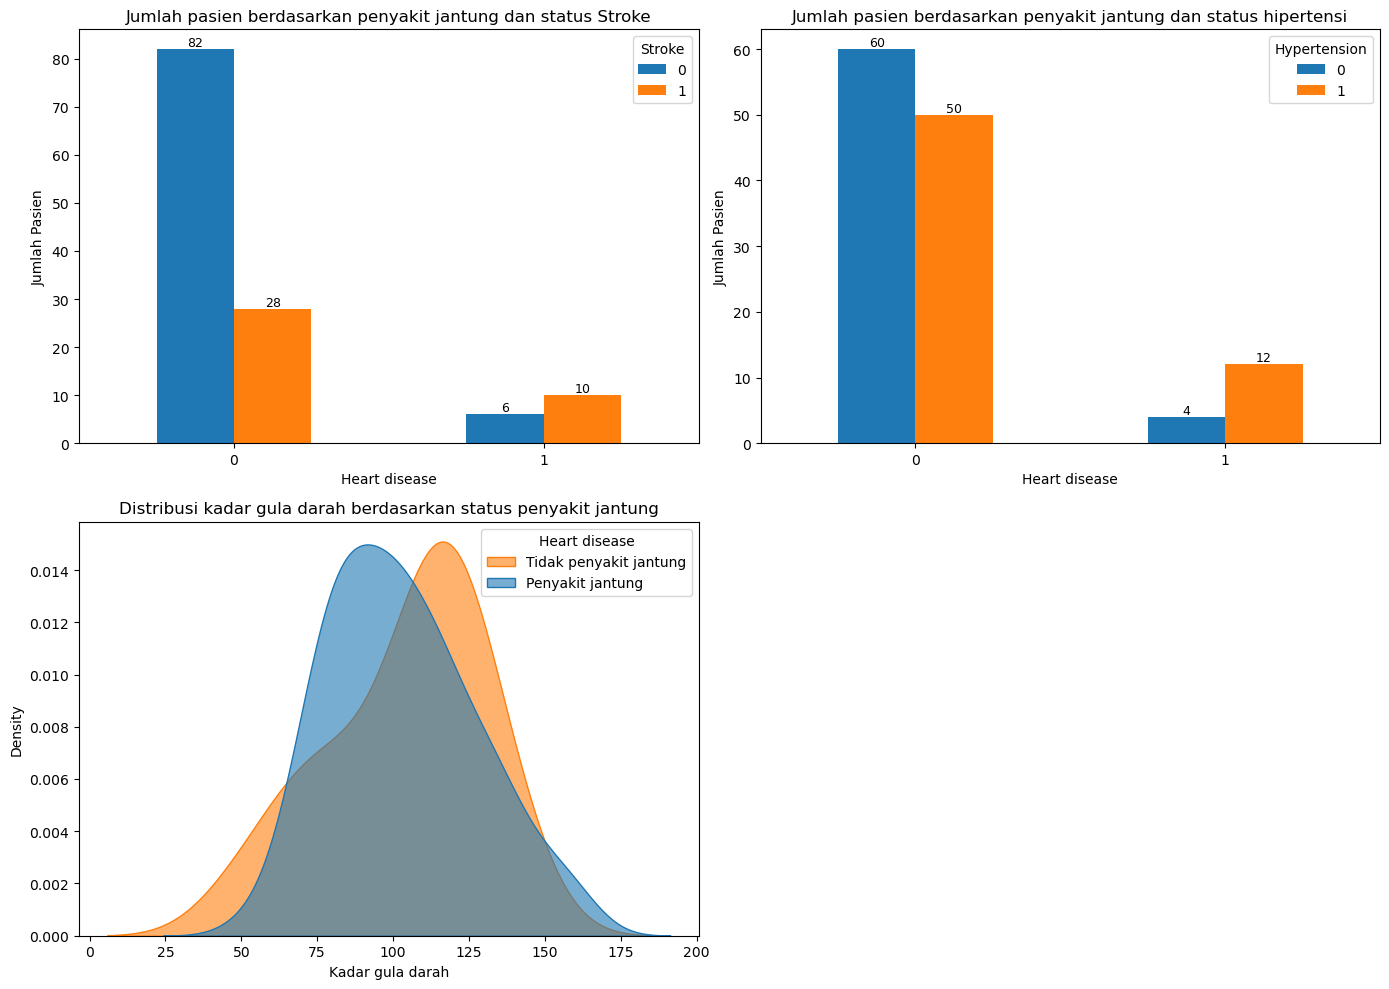

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat figure 2 baris x 2 kolom
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ----------------------------------------
# 1. Bar chart: heart_disease vs stroke
xy1 = df_clean.groupby(["heart_disease", "stroke"], observed=True)["id"].nunique().unstack()
xy1.plot(kind="bar", ax=axes[0,0])
axes[0,0].set_title("Jumlah pasien berdasarkan penyakit jantung dan status Stroke")
axes[0,0].set_xlabel("Heart disease")
axes[0,0].set_ylabel("Jumlah Pasien")
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)
axes[0,0].legend(title="Stroke")

for container in axes[0,0].containers:
    axes[0,0].bar_label(container, label_type="edge", fontsize=9)

# ----------------------------------------
# 2. Bar chart: heart_disease vs hypertension
xy2 = df_clean.groupby(["heart_disease", "hypertension"], observed=True)["id"].nunique().unstack()
xy2.plot(kind="bar", ax=axes[0,1])
axes[0,1].set_title("Jumlah pasien berdasarkan penyakit jantung dan status hipertensi")
axes[0,1].set_xlabel("Heart disease")
axes[0,1].set_ylabel("Jumlah Pasien")
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)
axes[0,1].legend(title="Hypertension")

for container in axes[0,1].containers:
    axes[0,1].bar_label(container, label_type="edge", fontsize=9)

# ----------------------------------------
# 3. KDE: Avg glucose level vs heart_disease
sns.kdeplot(
    data=df_clean,
    x="avg_glucose_level",
    hue="heart_disease",
    fill=True,
    common_norm=False,
    alpha=0.6,
    ax=axes[1,0]
)
axes[1,0].set_title("Distribusi kadar gula darah berdasarkan status penyakit jantung")
axes[1,0].set_xlabel("Kadar gula darah")
axes[1,0].set_ylabel("Density")
axes[1,0].legend(
    title="Heart disease",
    labels=["Tidak penyakit jantung", "Penyakit jantung"]
)

# ----------------------------------------
# Hapus subplot kosong
fig.delaxes(axes[1,1])

# Layout rapi
plt.tight_layout()
plt.show()

Hasil Analisis :
- Kadar gula darah tinggi dapat merusak lapisan pembuluh darah dan memicu penyempitan pembuluh darah.
- Hipertensi membuat jantung bekerja lebih keras untuk memompa darah.
- Kombinasi gula darah tinggi dan hipertensi mempercepat kerusakan pembuluh darah dan jantung.

### Hypertension

Sumber : 
- https://www.bing.com/ck/a?!&&p=77e295ff068e5aac06c5a469e1f7ba2ef2da075c90b92fb3810870f4220301d3JmltdHM9MTc2ODg2NzIwMA&ptn=3&ver=2&hsh=4&fclid=120b6770-653b-6eae-1be8-77c8645e6f65&psq=apakah+ada+hubungan+antara+hipertensi+dan+pekerjaan%3f&u=a1aHR0cHM6Ly9qdXJuYWwudWdtLmFjLmlkL2JrbS9hcnRpY2xlL2Rvd25sb2FkLzI1NzgzLzIwNTU4
- hubungan tempat tinggal dan hipertensi
  https://www.bing.com/ck/a?!&&p=efdcab8061b8d1b460d56c6f2c9b63cd2e6ae21846d26a2d6b75e3ccb60779d4JmltdHM9MTc2ODg2NzIwMA&ptn=3&ver=2&hsh=4&fclid=120b6770-653b-6eae-1be8-77c8645e6f65&psq=hubungan+hipertensi+dengan+tempat+tinggal&u=a1aHR0cHM6Ly9yZXBvc2l0b3J5LnVpbmprdC5hYy5pZC9kc3BhY2UvYml0c3RyZWFtLzEyMzQ1Njc4OS8yODg4NS8xL0RJTkElMjBBRExJTkElMjBBTVUtRktJSy5wZGY
- Hubungan penyakit hipertensi dan jantung
https://jurnalpost.com/hubungan-hipertensi-dengan-penyakit-jantung/62391/

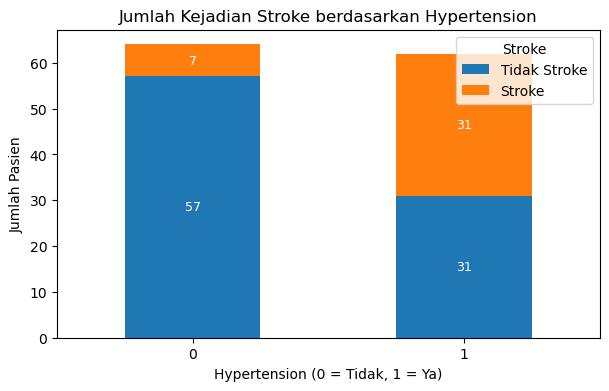

In [114]:
# Membuat tabel silang antara hypertension dan stroke 
ct = pd.crosstab(df_clean['hypertension'], df_clean['stroke'])

# Membuat stacked bar chart dari data jumlah
ax = ct.plot(
    kind='bar',
    stacked=True,
    figsize=(7,4)
)

# Judul dan label grafik
plt.title("Jumlah Kejadian Stroke berdasarkan Hypertension")
plt.xlabel("Hypertension (0 = Tidak, 1 = Ya)")
plt.ylabel("Jumlah Pasien")

# Legend
plt.legend(
    title="Stroke",
    labels=["Tidak Stroke", "Stroke"],
    loc="upper right"
)

# Agar label sumbu X tidak miring
plt.xticks(rotation=0)

# Loop manual berdasarkan data crosstab
for i in range(len(ct)):              # Loop tiap bar (0 dan 1)
    total = 0
    for val in ct.iloc[i]:            # Loop tiap bagian stack
        plt.text(
            i,                        # Posisi X (bar ke-i)
            total + val / 2,          # Tengah dari bagian stack
            int(val),                 # Nilai jumlah
            ha='center',
            va='center',
            color='white',
            fontsize=9
        )
        total += val                  # Menambah tinggi stack sebelumnya

# Menampilkan grafik
plt.show()

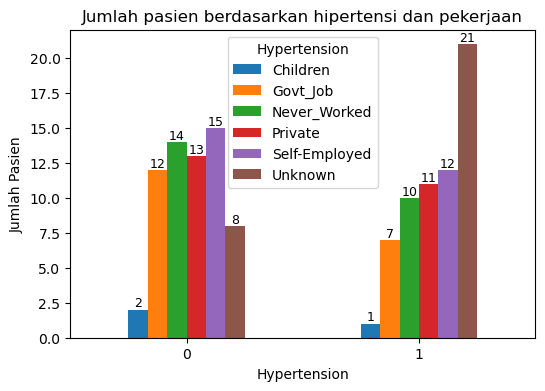

In [115]:
# Mengubah hasil groupby menjadi format tabel (kolom) agar mudah divisualisasikan
xy = df_clean.groupby(["hypertension", "final_work_type"], observed=True)["id"].nunique().unstack() # menggunakan unstack() agar lebih rapi bar chartnya tidak terpisah

# Membuat bar chart
ax = xy.plot(kind="bar", figsize=(6,4))

# Memberi judul dan label sumbu
plt.title("Jumlah pasien berdasarkan hipertensi dan pekerjaan")
plt.xlabel("Hypertension")
plt.ylabel("Jumlah Pasien")
plt.xticks(rotation=0)
plt.legend(title="Hypertension")

# Menambahkan anotasi nilai di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=9)

plt.show()

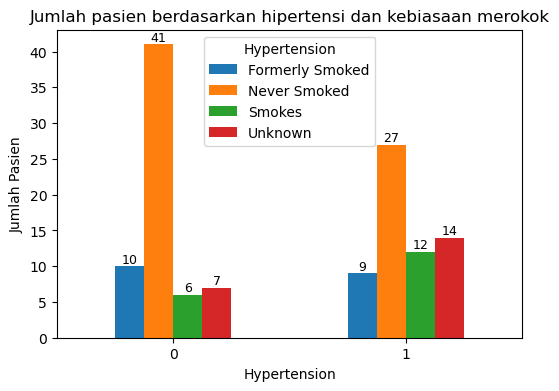

In [116]:
# Mengubah hasil groupby menjadi format tabel (kolom) agar mudah divisualisasikan
xy = df_clean.groupby(["hypertension", "smoking_status"], observed=True)["id"].nunique().unstack() # menggunakan unstack() agar lebih rapi bar chartnya tidak terpisah

# Membuat bar chart
ax = xy.plot(kind="bar", figsize=(6,4))

# Memberi judul dan label sumbu
plt.title("Jumlah pasien berdasarkan hipertensi dan kebiasaan merokok")
plt.xlabel("Hypertension")
plt.ylabel("Jumlah Pasien")
plt.xticks(rotation=0)
plt.legend(title="Hypertension")

# Menambahkan anotasi nilai di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=9)

plt.show()

Jenis tempat tinggal pasien:
1. rural = daerah pedesaan
2. urban = daerah perkotaan

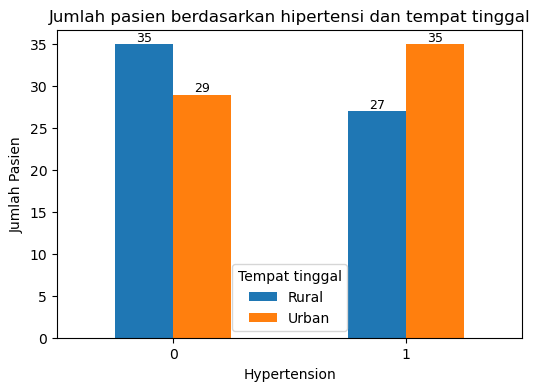

In [117]:
# Mengubah hasil groupby menjadi format tabel (kolom) agar mudah divisualisasikan
xy = df_clean.groupby(["hypertension", "Residence_type"], observed=True)["id"].nunique().unstack() # menggunakan unstack() agar lebih rapi bar chartnya tidak terpisah

# Membuat bar chart
ax = xy.plot(kind="bar", figsize=(6,4))

# Memberi judul dan label sumbu
plt.title("Jumlah pasien berdasarkan hipertensi dan tempat tinggal")
plt.xlabel("Hypertension")
plt.ylabel("Jumlah Pasien")
plt.xticks(rotation=0)
plt.legend(title="Tempat tinggal")

# Menambahkan anotasi nilai di atas setiap bar
for container in ax.containers:
    ax.bar_label(container, label_type="edge", fontsize=9)

plt.show()

- Gaya hidup masyarakat di perkotaan mayoritas kurang sehat seperti makanan cepat saji yang tidak sehat, dan kurang dalam berolahraga sehingga berisiko mengalami hipertensi
- Gaya hidup masyarakat di desa lebih sehat seperti banyak beraktivitas seperti hidup dari pertanian, sehingga lebih banyak makan sayur dan buah

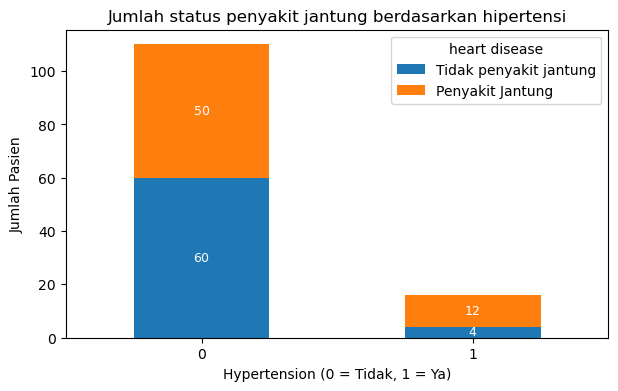

In [118]:
# Membuat tabel silang antara hypertension dan stroke 
ct = pd.crosstab(df_clean['heart_disease'], df_clean['hypertension'])

# Membuat stacked bar chart dari data jumlah
ax = ct.plot(
    kind='bar',
    stacked=True,
    figsize=(7,4)
)

# Judul dan label grafik
plt.title("Jumlah status penyakit jantung berdasarkan hipertensi")
plt.xlabel("Hypertension (0 = Tidak, 1 = Ya)")
plt.ylabel("Jumlah Pasien")

# Legend
plt.legend(
    title="heart disease",
    labels=["Tidak penyakit jantung", "Penyakit Jantung"],
    loc="upper right"
)

# Agar label sumbu X tidak miring
plt.xticks(rotation=0)

# Loop manual berdasarkan data crosstab
for i in range(len(ct)):              # Loop tiap bar (0 dan 1)
    total = 0
    for val in ct.iloc[i]:            # Loop tiap bagian stack
        plt.text(
            i,                        # Posisi X (bar ke-i)
            total + val / 2,          # Tengah dari bagian stack
            int(val),                 # Nilai jumlah
            ha='center',
            va='center',
            color='white',
            fontsize=9
        )
        total += val                  # Menambah tinggi stack sebelumnya

# Menampilkan grafik
plt.show()

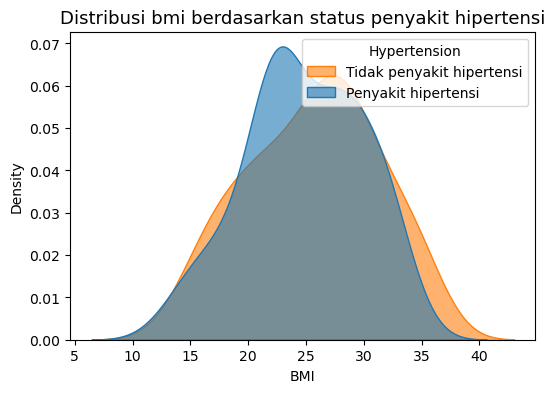

In [119]:
# Mengatur ukuran grafik agar mudah dibaca
plt.figure(figsize=(6,4))

# Membuat density plot (KDE) dengan hue
sns.kdeplot(
    data=df_clean,               # Dataset hasil cleaning
    x="bmi",       # Variabel numerik (kontinu)
    hue="hypertension",                # Pembeda kategori (0 = Tidak, 1 = Ya)
    fill=True,                   # Mengisi area density
    common_norm=False,           # Normalisasi terpisah tiap kelompok
    alpha=0.6                    # Transparansi agar tidak saling menutupi
)

# Memberi judul grafik
plt.title(
    "Distribusi bmi berdasarkan status penyakit hipertensi",
    fontsize=13
)

# Memberi label sumbu X dan Y
plt.xlabel("BMI")
plt.ylabel("Density")

# Mengatur legend agar informatif

plt.legend(
    title="Hypertension",
    labels=["Tidak penyakit hipertensi", "Penyakit hipertensi"],
    loc="upper right"
)

# Menampilkan grafik
plt.show()


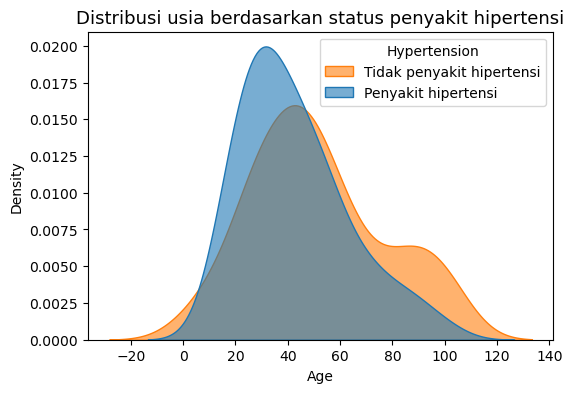

In [120]:
# Mengatur ukuran grafik agar mudah dibaca
plt.figure(figsize=(6,4))

# Membuat density plot (KDE) dengan hue
sns.kdeplot(
    data=df_clean,               # Dataset hasil cleaning
    x="age",       # Variabel numerik (kontinu)
    hue="hypertension",                # Pembeda kategori (0 = Tidak, 1 = Ya)
    fill=True,                   # Mengisi area density
    common_norm=False,           # Normalisasi terpisah tiap kelompok
    alpha=0.6                    # Transparansi agar tidak saling menutupi
)

# Memberi judul grafik
plt.title(
    "Distribusi usia berdasarkan status penyakit hipertensi",
    fontsize=13
)

# Memberi label sumbu X dan Y
plt.xlabel("Age")
plt.ylabel("Density")

# Mengatur legend agar informatif
plt.legend(
    title="Hypertension",
    labels=["Tidak penyakit hipertensi", "Penyakit hipertensi"],
    loc="upper right"
)

# Menampilkan grafik
plt.show()

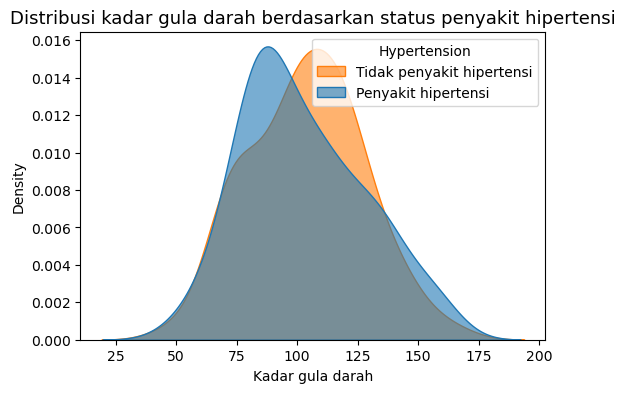

In [121]:
# Mengatur ukuran grafik agar mudah dibaca
plt.figure(figsize=(6,4))

# Membuat density plot (KDE) dengan hue
sns.kdeplot(
    data=df_clean,               # Dataset hasil cleaning
    x="avg_glucose_level",       # Variabel numerik (kontinu)
    hue="hypertension",                # Pembeda kategori (0 = Tidak, 1 = Ya)
    fill=True,                   # Mengisi area density
    common_norm=False,           # Normalisasi terpisah tiap kelompok
    alpha=0.6                    # Transparansi agar tidak saling menutupi
)

# Memberi judul grafik
plt.title(
    "Distribusi kadar gula darah berdasarkan status penyakit hipertensi",
    fontsize=13
)

# Memberi label sumbu X dan Y
plt.xlabel("Kadar gula darah")
plt.ylabel("Density")

# Mengatur legend agar informatif
plt.legend(
    title="Hypertension",
    labels=["Tidak penyakit hipertensi", "Penyakit hipertensi"],
    loc="upper right"
)

# Menampilkan grafik
plt.show()

Kadar gula darah yang tinggi dapat meningkatkan risiko hipertensi karena gula berlebih membuat tubuh menahan lebih banyak cairan, sehingga volume darah meningkat dan tekanan darah naik. Selain itu, gula darah tinggi juga dapat membuat pembuluh darah menjadi kaku dan kurang elastis, sehingga aliran darah tidak lancar dan tekanan darah semakin meningkat.

Sumber : https://www.bing.com/ck/a?!&&p=d670350ed5f253c5de0a0b1e0cc2637eff71edeeab38198d0f77ba70d44b4bcaJmltdHM9MTc2ODk1MzYwMA&ptn=3&ver=2&hsh=4&fclid=120b6770-653b-6eae-1be8-77c8645e6f65&psq=hubungan+kadar+gula+darah+dan+hipertensi&u=a1aHR0cHM6Ly9lanVybmFsLnVuaXNtLmFjLmlkL2luZGV4LnBocC9KTkkvYXJ0aWNsZS9kb3dubG9hZC82NzcvMzE3LzM3MDY

Menggabungkan semua visualisasi

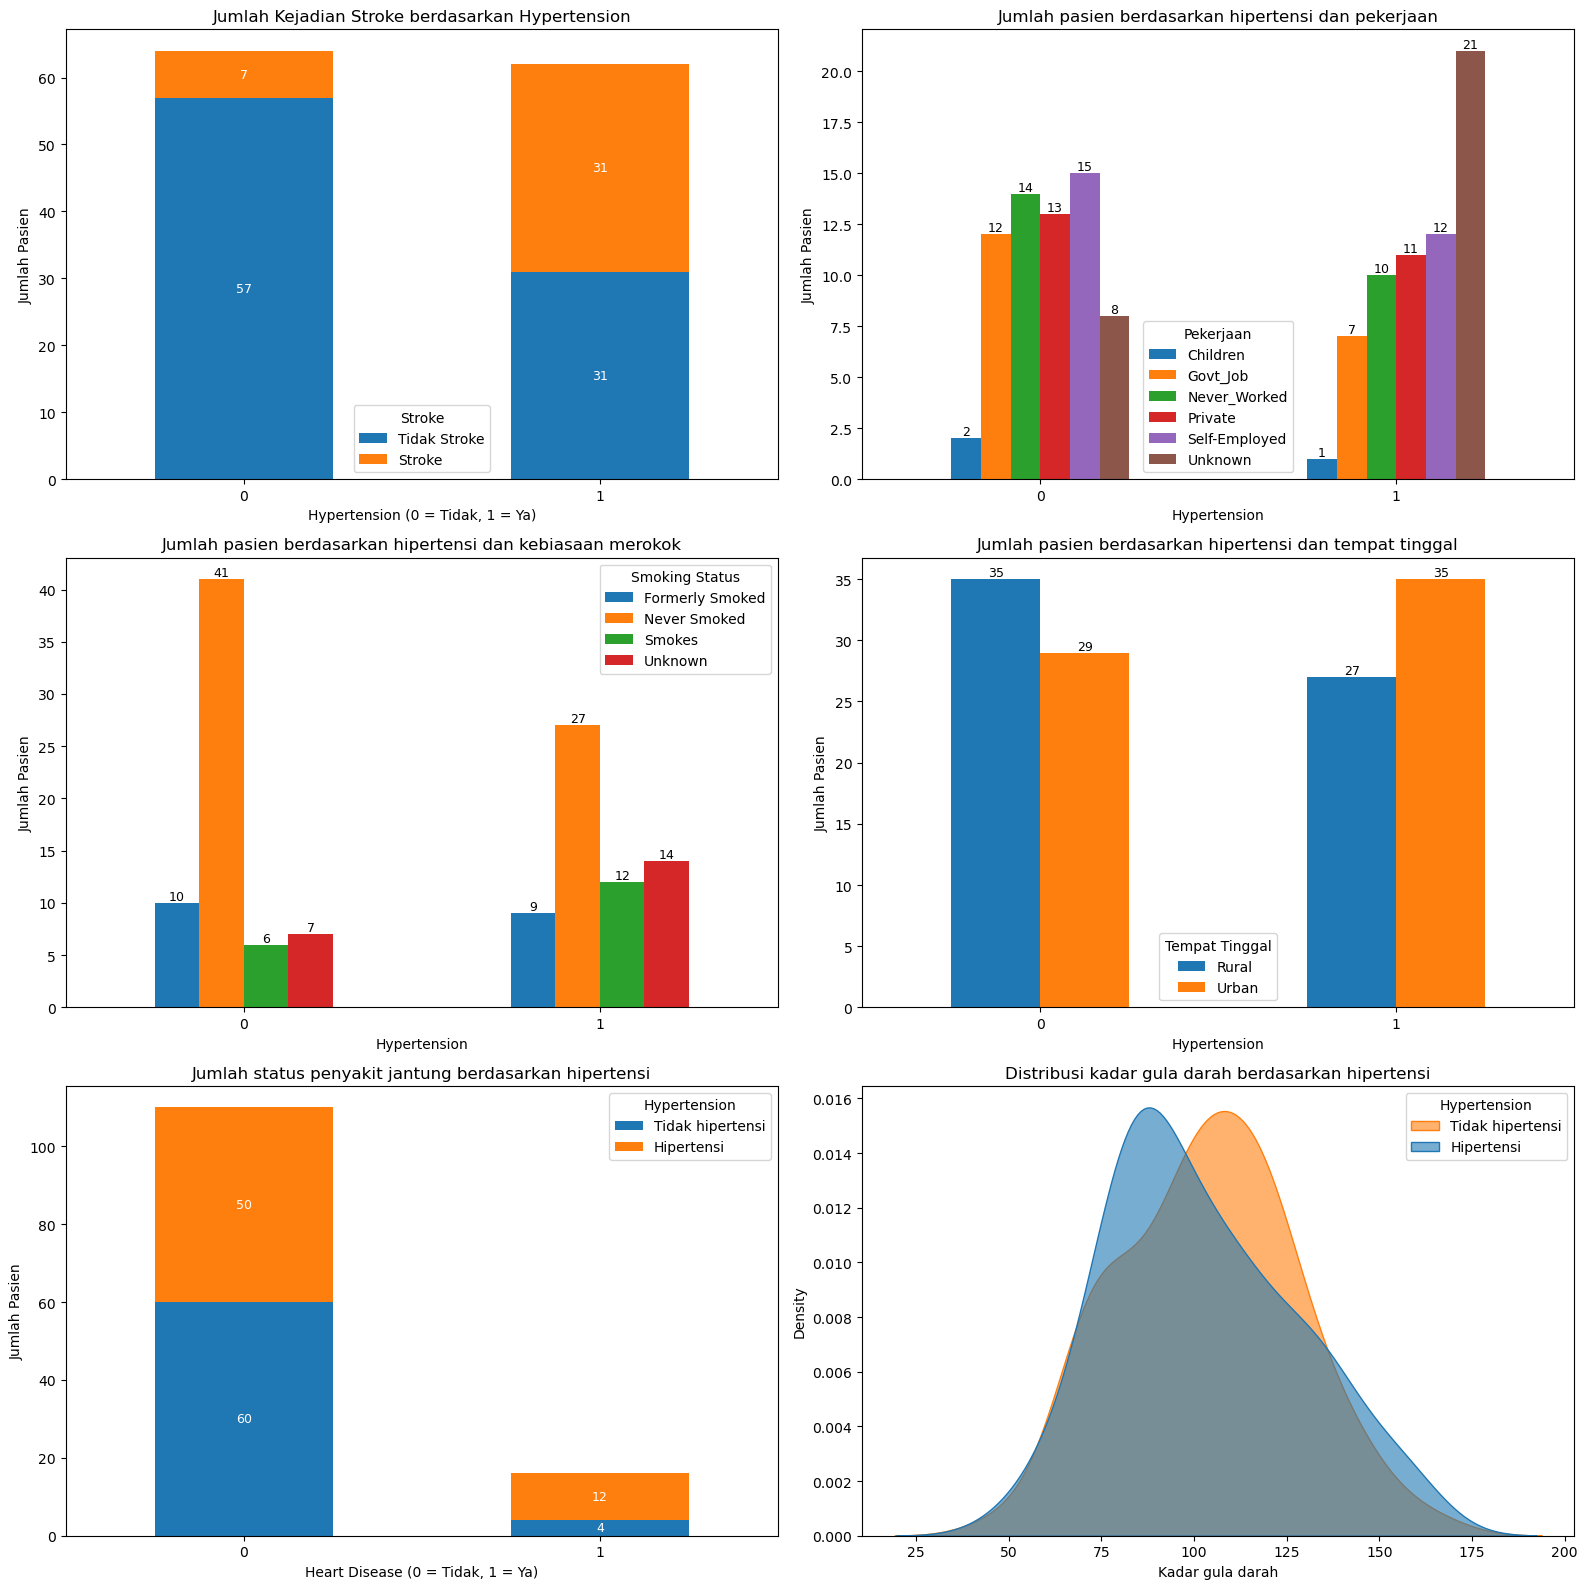

In [122]:
# Membuat figure 3 baris x 2 kolom
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# ---------------------------------------------------
# 1. Stacked bar: Hypertension vs Stroke
ct1 = pd.crosstab(df_clean['hypertension'], df_clean['stroke'])
ct1.plot(kind='bar', stacked=True, ax=axes[0,0])
axes[0,0].set_title("Jumlah Kejadian Stroke berdasarkan Hypertension")
axes[0,0].set_xlabel("Hypertension (0 = Tidak, 1 = Ya)")
axes[0,0].set_ylabel("Jumlah Pasien")
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)
axes[0,0].legend(title="Stroke", labels=["Tidak Stroke", "Stroke"])

for i in range(len(ct1)):
    total = 0
    for val in ct1.iloc[i]:
        axes[0,0].text(i, total + val/2, int(val),
                       ha='center', va='center', color='white', fontsize=9)
        total += val

# ---------------------------------------------------
# 2. Bar chart: Hypertension vs final_work_type
xy1 = df_clean.groupby(["hypertension", "final_work_type"], observed=True)["id"].nunique().unstack()
xy1.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Jumlah pasien berdasarkan hipertensi dan pekerjaan")
axes[0,1].set_xlabel("Hypertension")
axes[0,1].set_ylabel("Jumlah Pasien")
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)
axes[0,1].legend(title="Pekerjaan")

for container in axes[0,1].containers:
    axes[0,1].bar_label(container, label_type="edge", fontsize=9)

# ---------------------------------------------------
# 3. Bar chart: Hypertension vs smoking_status
xy2 = df_clean.groupby(["hypertension", "smoking_status"], observed=True)["id"].nunique().unstack()
xy2.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Jumlah pasien berdasarkan hipertensi dan kebiasaan merokok")
axes[1,0].set_xlabel("Hypertension")
axes[1,0].set_ylabel("Jumlah Pasien")
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=0)
axes[1,0].legend(title="Smoking Status")

for container in axes[1,0].containers:
    axes[1,0].bar_label(container, label_type="edge", fontsize=9)

# ---------------------------------------------------
# 4. Bar chart: Hypertension vs Residence_type
xy3 = df_clean.groupby(["hypertension", "Residence_type"], observed=True)["id"].nunique().unstack()
xy3.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title("Jumlah pasien berdasarkan hipertensi dan tempat tinggal")
axes[1,1].set_xlabel("Hypertension")
axes[1,1].set_ylabel("Jumlah Pasien")
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)
axes[1,1].legend(title="Tempat Tinggal")

for container in axes[1,1].containers:
    axes[1,1].bar_label(container, label_type="edge", fontsize=9)

# ---------------------------------------------------
# 5. Stacked bar: Heart disease vs Hypertension
ct2 = pd.crosstab(df_clean['heart_disease'], df_clean['hypertension'])
ct2.plot(kind='bar', stacked=True, ax=axes[2,0])
axes[2,0].set_title("Jumlah status penyakit jantung berdasarkan hipertensi")
axes[2,0].set_xlabel("Heart Disease (0 = Tidak, 1 = Ya)")
axes[2,0].set_ylabel("Jumlah Pasien")
axes[2,0].set_xticklabels(axes[2,0].get_xticklabels(), rotation=0)
axes[2,0].legend(title="Hypertension",
                  labels=["Tidak hipertensi", "Hipertensi"])

for i in range(len(ct2)):
    total = 0
    for val in ct2.iloc[i]:
        axes[2,0].text(i, total + val/2, int(val),
                       ha='center', va='center', color='white', fontsize=9)
        total += val

# ---------------------------------------------------
# 6. KDE: Avg Glucose Level vs Hypertension
sns.kdeplot(
    data=df_clean,
    x="avg_glucose_level",
    hue="hypertension",
    fill=True,
    common_norm=False,
    alpha=0.6,
    ax=axes[2,1]
)
axes[2,1].set_title("Distribusi kadar gula darah berdasarkan hipertensi")
axes[2,1].set_xlabel("Kadar gula darah")
axes[2,1].set_ylabel("Density")
axes[2,1].legend(title="Hypertension",
                  labels=["Tidak hipertensi", "Hipertensi"])

# ---------------------------------------------------
# Layout rapi
plt.tight_layout()
plt.show()

Hasil Analisis :
- Kadar gula darah tinggi menyebabkan tubuh menahan lebih banyak cairan dan membuat pembuluh darah kaku, sehingga tekanan darah meningkat.
- Kebiasaan merokok setiap hari merupakan salah satu faktor risiko hipertensi.
- Gaya hidup tidak sehat (konsumsi makanan cepat saji dan kurang olahraga) meningkatkan risiko hipertensi, terutama di perkotaan.
- Gaya hidup aktif dengan konsumsi sayur dan buah lebih banyak membantu menurunkan risiko hipertensi.
- Aktivitas fisik atau bekerja secara rutin dapat membantu mencegah hipertensi.

### Usia VS Stroke

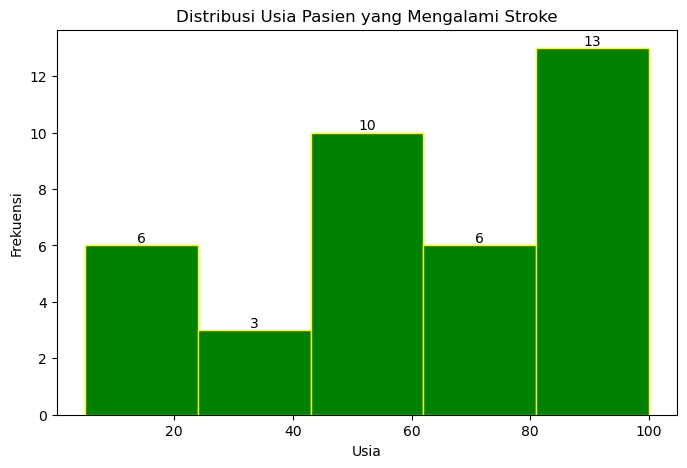

In [82]:
# Memfilter data pasien yang mengalami stroke
df_stroke = df[df['stroke'] == 1]

# Mengatur ukuran grafik
plt.figure(figsize=(8,5))

# Membuat histogram usia pasien stroke
counts, bins, _ = plt.hist(
    df_stroke['age'],   # Data usia
    bins=5,             # Jumlah interval
    color='green',
    edgecolor='yellow'
)

# Menambahkan anotasi jumlah pada setiap batang
for i in range(len(counts)):
    plt.text(
        (bins[i] + bins[i+1]) / 2,   # Titik tengah bin
        counts[i],                   # Tinggi batang
        int(counts[i]),              # Nilai frekuensi
        ha='center',
        va='bottom'
    )

# Memberi label sumbu X dan Y
plt.xlabel('Usia')
plt.ylabel('Frekuensi')

# Memberi judul grafik
plt.title('Distribusi Usia Pasien yang Mengalami Stroke')

# Menampilkan grafik
plt.show()

pada data ini, usia lansia lebih rentang mengalami stroke

Terdapat hubungan yang signifikan antara usia dengan kejadian stroke perdarahan dan iskemik. Dengan batas usia di atas 45 tahun menunjukkan bahwa peningkatan usia memiliki hubungan yang signifikan dengan stroke

sumber https://www.bing.com/ck/a?!&&p=0828274fb84a426497260ad4c60c431418d78b2e680c8bc068541436c8c051c9JmltdHM9MTc2ODc4MDgwMA&ptn=3&ver=2&hsh=4&fclid=120b6770-653b-6eae-1be8-77c8645e6f65&psq=usia+dan+stroke&u=a1aHR0cHM6Ly9lam91cm5hbC5uZXVyb25hLndlYi5pZC9pbmRleC5waHAvbmV1cm9uYS9hcnRpY2xlL2Rvd25sb2FkLzY0Ni8zMDYvMjk5Nw

## Sample

In [83]:
N = 126
e = 0.05

# Rumus Slovin
n_sample = N / (1 + N * (e**2))

# Konversi ke integer dan simpan ke variabel
n_sample = int(n_sample)
print("Jumlah sampel yang diambil:", n_sample)

# Mengambil sampel
df_sample = df_clean.sample(n=n_sample, random_state=42)
df_sample


Jumlah sampel yang diambil: 95


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,final_work_type,glucose_category,bmi_category,age_category
73,74,Female,44,1,0,Yes,Never_Worked,Rural,100.26,30.11,Never Smoked,0,Never_Worked,Diabetes,Obese,Adult
19,20,Male,46,0,0,Yes,Children,Urban,79.79,27.54,Never Smoked,0,Unknown,Normal,Overweight,Adult
116,117,Female,62,1,1,Yes,Self-Employed,Urban,103.50,17.19,Never Smoked,1,Self-Employed,Prediabetes,Underweight,Adult
67,68,Female,84,1,1,Yes,Self-Employed,Urban,134.00,34.60,Never Smoked,1,Self-Employed,Diabetes,Obese,Elderly
94,95,Female,65,1,0,Yes,Private,Rural,114.52,14.93,Unknown,1,Private,Prediabetes,Underweight,Elderly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,59,Male,45,1,1,Yes,Never_Worked,Urban,115.49,19.31,Smokes,1,Never_Worked,Prediabetes,Normal,Adult
90,91,Male,6,1,0,No,Children,Rural,106.71,34.37,Formerly Smoked,0,Children,Prediabetes,Obese,Children
48,49,Female,100,1,1,Yes,Children,Rural,87.35,26.38,Smokes,1,Unknown,Normal,Overweight,Elderly
88,89,Female,38,0,0,Yes,Govt_Job,Urban,114.06,21.92,Formerly Smoked,0,Govt_Job,Prediabetes,Normal,Adult


### Visualisasi hasil sample

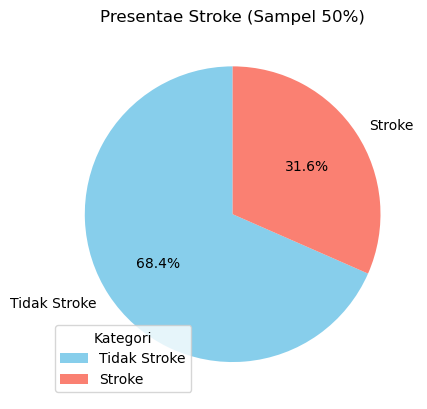

In [84]:
# Membuat pie chart proporsi stroke pada sampel
counts = df_sample['stroke'].value_counts()  # Menghitung jumlah masing-masing kategori
labels = ['Tidak Stroke', 'Stroke']          # Label kategori
colors = ['skyblue', 'salmon']              # Warna tiap kategori

# Membuat pie chart
plt.pie(
    counts, 
    labels=labels,       # Menambahkan label di pie chart
    autopct='%1.1f%%',  # Menampilkan persentase tiap bagian
    colors=colors,
    startangle=90        # Memutar chart agar dimulai dari atas
)

plt.title("Presentae Stroke (Sampel 50%)")   # Judul chart
plt.legend(labels, title="Kategori")        # Menambahkan legend
plt.ylabel("")                               # Menghilangkan label sumbu y
plt.show()


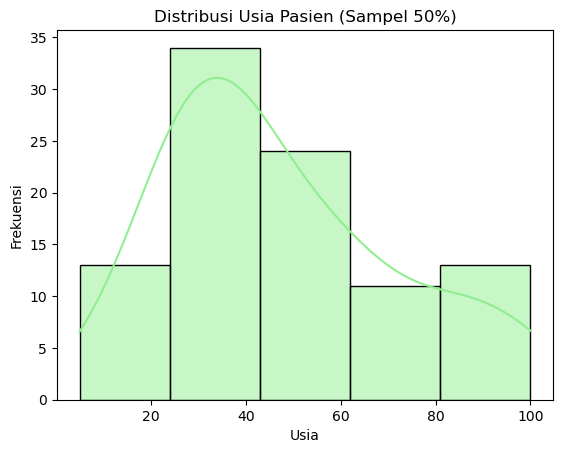

In [85]:
# Membuat histogram untuk distribusi usia pasien pada sampel
sns.histplot(
    df_sample['age'],   # Data numerik yang akan divisualisasikan (usia)
    bins=5,             # Membagi rentang usia menjadi 5 interval
    kde=True,           # Menambahkan kurva KDE (estimasi kepadatan distribusi)
    color='lightgreen'  # Warna histogram
)

# Menambahkan judul grafik
plt.title("Distribusi Usia Pasien (Sampel 50%)")

# Memberi label sumbu X
plt.xlabel("Usia")

# Memberi label sumbu Y
plt.ylabel("Frekuensi")

# Menampilkan grafik
plt.show()
